# Notebook 18 — Target-specific empirical eventless counterfactual and weights

This notebook implements Exercise 3 with a frozen target-specific event alignment. The canonical daily states and chronology are unchanged: Q_t, R_t, and I_t = iv_model_var remain indexed by model day [D-1 17:00 New York, D 17:00 New York).

Realised and implied variance use the same event-containing model day. Verified Bloomberg BGN metadata for USDJPYVON (ON ATM) states a 17:00–16:59 New York pricing session, aligned with the frozen 17:00-to-17:00 empirical model day.

## 1. Frozen upstream contract and reproducibility guardrails

Notebooks 15–17, n=1, m=12, the retained predictor blocks, OLS, chronological splits, and lag-before-mask interpretation are frozen. VALIDATION and TEST do not select the alignment rule. Existing N18 exports are loaded before overwrite only for realised-side invariance checks.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RUN_ID = pd.Timestamp.now(tz="UTC").isoformat()
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "Data" / "processed").exists()
)
PROCESSED = PROJECT_ROOT / "Data" / "processed"
INTERIM = PROJECT_ROOT / "Data" / "interim"
FIGURES = PROJECT_ROOT / "figures"

def parse_bool(value):
    text = str(value).strip().lower()
    if text in {"true", "1"}:
        return True
    if text in {"false", "0"}:
        return False
    raise ValueError(f"Cannot parse boolean: {value!r}")

def bool_series(series):
    mapped = series.astype(str).str.strip().str.lower().map(
        {"true": True, "false": False, "1": True, "0": False}
    )
    assert mapped.notna().all()
    return mapped.astype(bool)

spec16 = pd.read_csv(PROCESSED / "16_primary_specification.csv").iloc[0]
spec17 = pd.read_csv(PROCESSED / "17_primary_specification.csv").iloc[0]
expected_contract = {
    "iv_specification": "WEEKDAY_NORM_IV",
    "iv_column": "iv_model_var",
    "selected_n": 1,
    "selected_m": 12,
    "retain_Q_to_R": False,
    "retain_I_to_R": True,
    "retain_Q_to_I": True,
    "retain_R_to_I": True,
    "event_unaware": True,
    "eventless": False,
    "equation_5_implemented": False,
}
for key, expected in expected_contract.items():
    observed = (
        parse_bool(spec16[key]) if isinstance(expected, bool)
        else int(spec16[key]) if isinstance(expected, int)
        else str(spec16[key])
    )
    assert observed == expected, f"Frozen Notebook 16 contract mismatch: {key}={observed!r}"
assert parse_bool(spec17["exercise_2_complete"])
assert spec17["primary_realised_model"] == "R_PRIMARY_AR1_IV"
assert spec17["primary_implied_model"] == "I_PRIMARY_FULL_12"
IV_COLUMN = str(spec16["iv_column"])

def read_prior_export(filename, parse_dates=None):
    path = PROCESSED / filename
    return pd.read_csv(path, parse_dates=parse_dates) if path.exists() else pd.DataFrame()

prior_occurrences_export = read_prior_export("18_event_occurrences.csv", ["model_day"])
prior_target_mapping_export = read_prior_export("18_target_specific_event_mapping.csv", ["realised_model_day", "implied_model_day", "target_model_day"])
prior_coefficients_export = read_prior_export("18_eventless_coefficients.csv")
prior_forecasts_export = read_prior_export("18_eventless_forecasts.csv", ["model_day"])
prior_event_weights_export = read_prior_export("18_event_response_weights.csv", ["model_day"])
print(f"Frozen contract loaded: {IV_COLUMN}; n={int(spec16.selected_n)}, m={int(spec16.selected_m)}")

Frozen contract loaded: iv_model_var; n=1, m=12


## 2. Intact states and chronological lags

All 36 lags are constructed on the complete canonical chronology before any event mask. Event-day observations remain intact and can enter later forecasts as observed lagged states.

In [2]:
panel = (
    pd.read_csv(PROCESSED / "16_empirical_analysis_panel.csv", parse_dates=["model_day"])
    .sort_values("model_day")
    .reset_index(drop=True)
)
rv_source = (
    pd.read_csv(
        PROCESSED / "usdjpy_daily_model_panel.csv",
        usecols=[
            "model_day", "valid_hourly_return_count", "rv_complete_24h",
            "rv_full_session_stale", "rv_eligible",
        ],
        parse_dates=["model_day"],
    )
    .sort_values("model_day")
    .reset_index(drop=True)
)
for column in ["rv_complete_24h", "rv_full_session_stale", "rv_eligible"]:
    rv_source[column] = bool_series(rv_source[column])

required = {
    "model_day", "sample_split", "squared_return",
    "realised_variance_ann_252", IV_COLUMN,
}
assert required.issubset(panel.columns)
assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing
assert panel["model_day"].equals(rv_source["model_day"])

panel["Q"] = pd.to_numeric(panel["squared_return"], errors="coerce")
panel["R"] = pd.to_numeric(panel["realised_variance_ann_252"], errors="coerce")
panel["I"] = pd.to_numeric(panel[IV_COLUMN], errors="coerce")
state_snapshot = panel[["model_day", "Q", "R", "I"]].copy()

for state in ["Q", "R", "I"]:
    for lag in range(1, 13):
        panel[f"{state}_lag{lag}"] = panel[state].shift(lag)
lag_columns = [
    f"{state}_lag{lag}" for state in ["Q", "R", "I"] for lag in range(1, 13)
]
lag_snapshot = panel[["model_day", *lag_columns]].copy()
R_FEATURES = ["R_lag1", "I_lag1"]
I_FEATURES = [
    f"{state}_lag{lag}" for state in ["Q", "R", "I"] for lag in range(1, 13)
]
BASE_COLUMNS = {
    "R": ["R", "Q_lag1", "R_lag1", "I_lag1"],
    "I": ["I", *I_FEATURES],
}
for target in ["R", "I"]:
    panel[f"{target}_base_eligible"] = np.isfinite(panel[BASE_COLUMNS[target]]).all(axis=1)

base_counts = panel.groupby("sample_split")[
    ["R_base_eligible", "I_base_eligible"]
].sum().astype(int)
assert tuple(base_counts.loc["train"]) == (3005, 2226)
assert tuple(base_counts.loc["validation"]) == (1181, 1087)
split_dates = panel.groupby("sample_split")["model_day"].agg(["min", "max", "count"])
assert split_dates.loc["train", "min"] == pd.Timestamp("2003-05-05")
assert split_dates.loc["train", "max"] == pd.Timestamp("2017-03-27")
assert split_dates.loc["validation", "min"] == pd.Timestamp("2017-03-28")
assert split_dates.loc["test", "min"] == pd.Timestamp("2021-11-15")
display(base_counts)
display(split_dates)

,R_base_eligible,I_base_eligible
sample_split,,
test,1182,1071
train,3005,2226
validation,1181,1087


,min,max,count
sample_split,,,
test,2021-11-15,2026-07-02,1209
train,2003-05-05,2017-03-27,3626
validation,2017-03-28,2021-11-12,1209


## 3. Six-family occurrences and target-specific alignment

Raw Bloomberg component rows are parsed and session-mapped exactly as before, then collapsed to coherent family × realised-model-day occurrences. Verified Bloomberg pricing-session metadata makes the production implied target the same event-containing empirical model day. Notebook 18A's earlier intraday-cut diagnostic is superseded for production alignment.

In [3]:
FAMILY_LABELS = {
    "FOMC": ["FOMC Rate Decision (Upper Bound)"],
    "US Employment": ["Change in Nonfarm Payrolls", "Unemployment Rate"],
    "US CPI": ["CPI MoM", "CPI YoY"],
    "BoJ": ["BOJ Target Rate"],
    "JPY National CPI": ["Natl CPI YoY"],
    "JPY GDP": ["GDP SA QoQ", "GDP Annualized SA QoQ", "GDP Deflator YoY"],
}
label_to_family = {
    label: family for family, labels in FAMILY_LABELS.items() for label in labels
}
event_family_mapping = pd.DataFrame(
    [(label, family) for label, family in label_to_family.items()],
    columns=["raw_event_label", "mapped_family"],
)

raw_events = pd.read_csv(INTERIM / "g10_usd_jpy_events_audited.csv")
raw_events = (
    raw_events.loc[raw_events["event"].isin(label_to_family)]
    .copy()
    .reset_index(names="raw_event_id")
)
raw_events["raw_event_label"] = raw_events["event"]
raw_events["mapped_family"] = raw_events["event"].map(label_to_family)
raw_events["event_timestamp_original"] = raw_events["event_datetime_utc"].astype(str)
raw_events["event_datetime_utc"] = pd.to_datetime(
    raw_events["event_datetime_utc"], utc=True, errors="coerce", format="mixed"
)
raw_events["event_datetime_ny"] = raw_events["event_datetime_utc"].dt.tz_convert(
    "America/New_York"
)

sessions = pd.DataFrame({"model_day": panel["model_day"]})
sessions["session_open_naive"] = (
    sessions["model_day"] - pd.Timedelta(days=1) + pd.Timedelta(hours=17)
)
sessions["session_close_naive"] = sessions["model_day"] + pd.Timedelta(hours=17)
sessions["session_open_ny"] = sessions["session_open_naive"].dt.tz_localize(
    "America/New_York"
)
sessions["session_close_ny"] = sessions["session_close_naive"].dt.tz_localize(
    "America/New_York"
)
sessions["session_open_utc"] = sessions["session_open_ny"].dt.tz_convert("UTC")
sessions["session_close_utc"] = sessions["session_close_ny"].dt.tz_convert("UTC")
assert sessions["session_open_ny"].dt.hour.eq(17).all()
assert sessions["session_close_ny"].dt.hour.eq(17).all()

valid_events = (
    raw_events.loc[raw_events["event_datetime_utc"].notna()]
    .sort_values("event_datetime_utc")
    .copy()
)
probed = pd.merge_asof(
    valid_events,
    sessions[[
        "model_day", "session_open_utc", "session_close_utc",
    ]].sort_values("session_open_utc"),
    left_on="event_datetime_utc",
    right_on="session_open_utc",
    direction="backward",
)
probed["explicit_member"] = (
    probed["session_open_utc"].le(probed["event_datetime_utc"])
    & probed["event_datetime_utc"].lt(probed["session_close_utc"])
)
probed["mapped_model_day"] = probed["model_day"].where(probed["explicit_member"])
panel_start = sessions["session_open_utc"].min()
panel_end = sessions["session_close_utc"].max()
probed["mapping_status"] = np.select(
    [
        probed["explicit_member"],
        ~probed["event_datetime_utc"].between(
            panel_start, panel_end, inclusive="both"
        ),
    ],
    ["MAPPED", "OUTSIDE_EMPIRICAL_PANEL"],
    default="NO_EXISTING_SESSION_INTERVAL",
)
mapping_audit = raw_events[[
    "raw_event_id", "raw_event_label", "mapped_family",
    "event_timestamp_original", "event_datetime_utc", "event_datetime_ny",
]].merge(
    probed[[
        "raw_event_id", "mapped_model_day", "mapping_status", "explicit_member",
    ]],
    on="raw_event_id",
    how="left",
)
mapping_audit["mapping_status"] = mapping_audit["mapping_status"].fillna(
    "INVALID_TIMESTAMP"
)
mapping_audit["explicit_member"] = mapping_audit["explicit_member"].eq(True)
mapping_audit["mapped_model_day"] = pd.to_datetime(
    mapping_audit["mapped_model_day"]
)
display(mapping_audit["mapping_status"].value_counts().to_frame("raw_rows"))

,raw_rows
mapping_status,
MAPPED,2315
OUTSIDE_EMPIRICAL_PANEL,310
NO_EXISTING_SESSION_INTERVAL,1


In [4]:
modelled_raw = mapping_audit.loc[mapping_audit["mapping_status"].eq("MAPPED")].copy()
assert bool(modelled_raw["explicit_member"].all() and modelled_raw["event_datetime_utc"].notna().all())
occurrences = (modelled_raw.groupby(["mapped_family","mapped_model_day"],as_index=False).agg(raw_row_count=("raw_event_id","size"),raw_labels=("raw_event_label",lambda x:" | ".join(sorted(set(x))),),n_unique_raw_timestamps=("event_datetime_utc","nunique"),first_event_time_utc=("event_datetime_utc","min"),last_event_time_utc=("event_datetime_utc","max")).rename(columns={"mapped_family":"family","mapped_model_day":"realised_model_day"}))
first_original=(modelled_raw.sort_values("event_datetime_utc").drop_duplicates(["mapped_family","mapped_model_day"])[["mapped_family","mapped_model_day","event_timestamp_original"]].rename(columns={"mapped_family":"family","mapped_model_day":"realised_model_day"}))
occurrences=occurrences.merge(first_original,on=["family","realised_model_day"],how="left",validate="one_to_one")
occurrences["release_span_seconds"]=(occurrences.last_event_time_utc-occurrences.first_event_time_utc).dt.total_seconds()
occurrences["event_id"]=occurrences.family.str.replace(r"[^A-Za-z0-9]+","_",regex=True).str.strip("_")+"__"+occurrences.realised_model_day.dt.strftime("%Y%m%d")
occurrences["event_label"]=occurrences.family
occurrences["event_timestamp_utc"]=occurrences.first_event_time_utc
occurrences["event_timestamp_ny"]=occurrences.event_timestamp_utc.dt.tz_convert("America/New_York")
occurrences["bloomberg_pricing_day_end_ny"]=(pd.to_datetime(occurrences.realised_model_day.dt.date)+pd.Timedelta(hours=16,minutes=59)).dt.tz_localize("America/New_York")
occurrences["edge_1659_to_1700"]=(occurrences.event_timestamp_ny.dt.hour.eq(16)&occurrences.event_timestamp_ny.dt.minute.eq(59)&occurrences.event_timestamp_ny.dt.second.gt(0))
edge_case_audit=occurrences.loc[occurrences.edge_1659_to_1700,["event_id","family","event_timestamp_original","event_timestamp_utc","event_timestamp_ny","realised_model_day"]].copy()
assert edge_case_audit.empty,"16:59–17:00 Bloomberg session-edge events require human review."
split_lookup=panel.set_index("model_day").sample_split
occurrences["old_implied_model_day"]=pd.NaT
if len(prior_target_mapping_export):
    old_i=prior_target_mapping_export.loc[prior_target_mapping_export.target.eq("I"),["event_id","target_model_day"]].rename(columns={"target_model_day":"old_implied_model_day"})
    occurrences=occurrences.drop(columns="old_implied_model_day").merge(old_i,on="event_id",how="left",validate="one_to_one")
occurrences["implied_model_day"]=occurrences.realised_model_day
occurrences["implied_shift_model_days"]=0
occurrences["realised_target_day_available"]=occurrences.realised_model_day.isin(panel.model_day)
occurrences["implied_target_day_available"]=occurrences.implied_model_day.isin(panel.model_day)
occurrences["realised_sample_split"]=occurrences.realised_model_day.map(split_lookup)
occurrences["implied_sample_split"]=occurrences.implied_model_day.map(split_lookup)
assert occurrences.realised_target_day_available.all() and occurrences.implied_target_day_available.all()
assert occurrences.loc[~occurrences.edge_1659_to_1700,"implied_model_day"].eq(occurrences.loc[~occurrences.edge_1659_to_1700,"realised_model_day"]).all()
occurrences["model_day"]=occurrences.realised_model_day; occurrences["model_day_role"]="REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS"; occurrences["sample_split"]=occurrences.realised_sample_split
old_index=panel.reset_index().set_index("model_day")["index"]
timing_correction_audit=occurrences[["event_id","family","event_timestamp_ny","realised_model_day","old_implied_model_day","implied_model_day"]].rename(columns={"family":"event_family","implied_model_day":"new_implied_model_day"}).copy()
timing_correction_audit["mapping_changed"]=timing_correction_audit.old_implied_model_day.notna()&timing_correction_audit.old_implied_model_day.ne(timing_correction_audit.new_implied_model_day)
timing_correction_audit["old_shift_days_or_rows"]=timing_correction_audit.old_implied_model_day.map(old_index)-timing_correction_audit.realised_model_day.map(old_index)
def make_target_day_flags(target,day_column):
    flags=(occurrences.loc[occurrences[day_column].notna()].groupby(day_column,as_index=False).agg(n_target_occurrences=("event_id","size"),n_target_families=("family","nunique"),family_set=("family",lambda x:" | ".join(sorted(set(x))))).rename(columns={day_column:"model_day"}))
    flags["is_target_event_day"]=True; flags["is_clean_single_family"]=flags.n_target_families.eq(1); flags["is_overlap"]=flags.n_target_families.gt(1); flags["target"]=target
    return flags
R_day_flags=make_target_day_flags("R","realised_model_day"); I_day_flags=make_target_day_flags("I","implied_model_day"); target_day_flags=pd.concat([R_day_flags,I_day_flags],ignore_index=True)
event_day_flags=panel[["model_day"]].copy()
for target,flags in [("R",R_day_flags),("I",I_day_flags)]:
    renamed=flags.drop(columns="target").rename(columns={column:f"{target}_{column}" for column in flags.columns if column!="model_day"})
    event_day_flags=event_day_flags.merge(renamed,on="model_day",how="left",validate="one_to_one")
    for column in [f"{target}_n_target_occurrences",f"{target}_n_target_families"]: event_day_flags[column]=event_day_flags[column].fillna(0).astype(int)
    event_day_flags[f"{target}_family_set"]=event_day_flags[f"{target}_family_set"].fillna("")
    for column in [f"{target}_is_target_event_day",f"{target}_is_clean_single_family",f"{target}_is_overlap"]: event_day_flags[column]=event_day_flags[column].eq(True)
for legacy,source in {"n_target_families":"R_n_target_families","family_set":"R_family_set","is_target_event_day":"R_is_target_event_day","is_clean_single_family":"R_is_clean_single_family","is_overlap":"R_is_overlap"}.items(): event_day_flags[legacy]=event_day_flags[source]
row_count_before_merge=len(panel); panel=panel.merge(event_day_flags,on="model_day",how="left",validate="one_to_one")
lags_preserved_after_event_merge=len(panel)==row_count_before_merge and panel[["model_day",*lag_columns]].equals(lag_snapshot); states_preserved_after_event_merge=panel[["model_day","Q","R","I"]].equals(state_snapshot); assert lags_preserved_after_event_merge and states_preserved_after_event_merge
for target,day_column in [("R","realised_model_day"),("I","implied_model_day")]:
    lookup_columns=["model_day",f"{target}_n_target_occurrences",f"{target}_n_target_families",f"{target}_family_set",f"{target}_is_clean_single_family",f"{target}_is_overlap"]
    occurrences=occurrences.merge(event_day_flags[lookup_columns].rename(columns={"model_day":day_column}),on=day_column,how="left",validate="many_to_one")
occurrences["n_target_families"]=occurrences["R_n_target_families"]; occurrences["family_set"]=occurrences["R_family_set"]; occurrences["is_clean_single_family"]=occurrences["R_is_clean_single_family"]; occurrences["is_overlap"]=occurrences["R_is_overlap"]
mapping_parts=[]
for target,day_column,split_column in [("R","realised_model_day","realised_sample_split"),("I","implied_model_day","implied_sample_split")]:
    part=occurrences.copy(); part["target"]=target; part["target_model_day"]=part[day_column]; part["target_model_day_available"]=part[f"{'realised' if target=='R' else 'implied'}_target_day_available"]; part["sample_split"]=part[split_column]; part["model_day"]=part.target_model_day; part["model_day_role"]="TARGET_SPECIFIC_RESPONSE_DAY"; part["n_target_occurrences"]=part[f"{target}_n_target_occurrences"]; part["n_target_families"]=part[f"{target}_n_target_families"]; part["family_set"]=part[f"{target}_family_set"]; part["is_clean_single_family"]=part[f"{target}_is_clean_single_family"]; part["is_overlap"]=part[f"{target}_is_overlap"]; mapping_parts.append(part)
target_specific_event_mapping=pd.concat(mapping_parts,ignore_index=True)
assert not occurrences.duplicated(["family","realised_model_day"]).any() and occurrences.event_id.is_unique
assert occurrences.release_span_seconds.max()<=6 and occurrences.event_timestamp_utc.eq(occurrences.first_event_time_utc).all()
if len(prior_occurrences_export):
    prior_col="realised_model_day" if "realised_model_day" in prior_occurrences_export else "model_day"
    prior_realised=prior_occurrences_export[["family",prior_col]].rename(columns={prior_col:"realised_model_day"}); prior_realised.realised_model_day=pd.to_datetime(prior_realised.realised_model_day)
    assert prior_realised.sort_values(["family","realised_model_day"]).reset_index(drop=True).equals(occurrences[["family","realised_model_day"]].sort_values(["family","realised_model_day"]).reset_index(drop=True))
old_R_days=set(prior_target_mapping_export.loc[prior_target_mapping_export.target.eq("R"),"target_model_day"]) if len(prior_target_mapping_export) else set(occurrences.realised_model_day)
assert old_R_days==set(occurrences.realised_model_day)
alignment_mapping_summary=(timing_correction_audit.groupby("event_family",as_index=False).agg(n_occurrences=("event_id","size"),n_mapping_changed=("mapping_changed","sum")).assign(fraction_changed=lambda x:x.n_mapping_changed/x.n_occurrences))
print("Bloomberg same-model-day alignment checks passed."); display(alignment_mapping_summary)


Bloomberg same-model-day alignment checks passed.


,event_family,n_occurrences,n_mapping_changed,fraction_changed
0,BoJ,221,0,0.0
1,FOMC,189,0,0.0
2,JPY GDP,174,0,0.0
3,JPY National CPI,277,0,0.0
4,US CPI,277,0,0.0
5,US Employment,276,0,0.0


## 4. Target-specific eventless masks and support

R target observations are excluded on the union of realised_model_day. I target observations are excluded on the union of implied_model_day. A shared target day is masked once. Chronology rows and historical lagged event states are retained.

In [5]:
support = (
    occurrences.groupby(["family", "realised_sample_split"]).size()
    .unstack(fill_value=0)
    .reindex(index=list(FAMILY_LABELS), columns=["train", "validation"], fill_value=0)
)
expected_support = {
    "FOMC": (114, 38),
    "US Employment": (166, 56),
    "US CPI": (167, 56),
    "BoJ": (146, 38),
    "JPY National CPI": (165, 56),
    "JPY GDP": (99, 37),
}
for family, expected in expected_support.items():
    assert tuple(support.loc[family]) == expected

for target in ["R", "I"]:
    panel[f"{target}_eventless_eligible"] = (
        panel[f"{target}_base_eligible"]
        & ~panel[f"{target}_is_target_event_day"]
    )
assert int(panel.loc[
    panel["sample_split"].eq("train"), "R_eventless_eligible"
].sum()) == 2321
assert int(panel.loc[
    panel["sample_split"].eq("validation"), "R_eventless_eligible"
].sum()) == 919

support_rows = []
for stage, splits in [
    ("TRAIN", ["train"]),
    ("TRAIN_PLUS_VALIDATION", ["train", "validation"]),
]:
    for target in ["R", "I"]:
        scope = panel["sample_split"].isin(splits)
        base_n = int((scope & panel[f"{target}_base_eligible"]).sum())
        removed_n = int((
            scope
            & panel[f"{target}_base_eligible"]
            & panel[f"{target}_is_target_event_day"]
        ).sum())
        eventless_n = int((scope & panel[f"{target}_eventless_eligible"]).sum())
        assert eventless_n == base_n - removed_n
        support_rows.append({
            "stage": stage,
            "target": target,
            "base_eligible_N": base_n,
            "eligible_target_event_N_removed": removed_n,
            "eventless_calibration_N": eventless_n,
            "fraction_retained": eventless_n / base_n,
            "target_event_day_definition": (
                "realised_model_day" if target == "R" else "implied_model_day"
            ),
        })
table_18_2 = pd.DataFrame(support_rows)

table_18_1 = pd.DataFrame({
    "family": list(FAMILY_LABELS),
    "raw_labels": [" | ".join(FAMILY_LABELS[f]) for f in FAMILY_LABELS],
})
for target, day_column, split_column in [
    ("R", "realised_model_day", "realised_sample_split"),
    ("I", "implied_model_day", "implied_sample_split"),
]:
    for split, prefix in [("train", "TRAIN"), ("validation", "VALIDATION")]:
        rows = occurrences.loc[occurrences[split_column].eq(split)].copy()
        eligibility = panel.set_index("model_day")[f"{target}_base_eligible"]
        rows["target_eligible"] = rows[day_column].map(eligibility).eq(True)
        grouped = rows.groupby("family").agg(
            event_occurrences=("event_id", "size"),
            target_eligible=("target_eligible", "sum"),
        ).reindex(list(FAMILY_LABELS), fill_value=0)
        table_18_1[f"{prefix} {target} occurrences"] = grouped[
            "event_occurrences"
        ].to_numpy()
        table_18_1[f"{prefix} {target}-eligible occurrences"] = grouped[
            "target_eligible"
        ].to_numpy()

assert panel[["model_day", *lag_columns]].equals(lag_snapshot)
assert panel[["model_day", "Q", "R", "I"]].equals(state_snapshot)
print("Table 18.1 — target-specific family support")
display(table_18_1)
print("Table 18.2 — target-specific eventless calibration support")
display(table_18_2)

Table 18.1 — target-specific family support


,family,raw_labels,TRAIN R occurrences,TRAIN R-eligible occurrences,VALIDATION R occurrences,VALIDATION R-eligible occurrences,TRAIN I occurrences,TRAIN I-eligible occurrences,VALIDATION I occurrences,VALIDATION I-eligible occurrences
0,FOMC,FOMC Rate Decision (Upper Bound),114,96,38,38,114,78,38,36
1,US Employment,Change in Nonfarm Payrolls | Unemployment Rate,166,137,56,55,166,101,56,50
2,US CPI,CPI MoM | CPI YoY,167,149,56,56,167,99,56,47
3,BoJ,BOJ Target Rate,146,131,38,38,146,115,38,38
4,JPY National CPI,Natl CPI YoY,165,138,56,55,165,112,56,55
5,JPY GDP,GDP SA QoQ | GDP Annualized SA QoQ | GDP Defla...,99,84,37,37,99,62,37,33


Table 18.2 — target-specific eventless calibration support


,stage,target,base_eligible_N,eligible_target_event_N_removed,eventless_calibration_N,fraction_retained,target_event_day_definition
0,TRAIN,R,3005,684,2321,0.772379,realised_model_day
1,TRAIN,I,2226,522,1704,0.765499,implied_model_day
2,TRAIN_PLUS_VALIDATION,R,4186,946,3240,0.774009,realised_model_day
3,TRAIN_PLUS_VALIDATION,I,3313,766,2547,0.768790,implied_model_day


## 5. Event-day realised-variance retention diagnostic

This uses Notebook 15's exact rv_complete_24h and rv_eligible fields. It does not redefine completeness or relax the 24/24, non-stale primary rule.

In [6]:
event_rv = occurrences.merge(
    rv_source,
    left_on="realised_model_day",
    right_on="model_day",
    how="left",
    validate="many_to_one",
)
assert event_rv["rv_eligible"].notna().all()
assert event_rv.loc[event_rv["rv_eligible"], "valid_hourly_return_count"].eq(24).all()

retention_rows = []
for split in ["train", "validation", "test", "ALL"]:
    split_events = (
        event_rv if split == "ALL"
        else event_rv.loc[event_rv["realised_sample_split"].eq(split)]
    )
    for family, group in split_events.groupby("family"):
        retention_rows.append({
            "scope": "EVENT_FAMILY",
            "sample_split": split,
            "family": family,
            "total_economic_occurrences": int(len(group)),
            "unique_realised_model_days": int(
                group["realised_model_day"].nunique()
            ),
            "n_complete_24h": int(group["rv_complete_24h"].sum()),
            "n_primary_rv_available": int(group["rv_eligible"].sum()),
            "retention_fraction": float(group["rv_eligible"].mean()),
        })

realised_event_days = set(occurrences["realised_model_day"])
ordinary_rv = panel[["model_day", "sample_split"]].merge(
    rv_source, on="model_day", how="left", validate="one_to_one"
)
ordinary_rv = ordinary_rv.loc[
    ~ordinary_rv["model_day"].isin(realised_event_days)
].copy()
for split in ["train", "validation", "test", "ALL"]:
    group = (
        ordinary_rv if split == "ALL"
        else ordinary_rv.loc[ordinary_rv["sample_split"].eq(split)]
    )
    retention_rows.append({
        "scope": "ORDINARY_DAY_CONTEXT",
        "sample_split": split,
        "family": "ORDINARY_DAYS",
        "total_economic_occurrences": int(len(group)),
        "unique_realised_model_days": int(group["model_day"].nunique()),
        "n_complete_24h": int(group["rv_complete_24h"].sum()),
        "n_primary_rv_available": int(group["rv_eligible"].sum()),
        "retention_fraction": float(group["rv_eligible"].mean()),
    })
event_rv_retention_audit = pd.DataFrame(retention_rows)
display(event_rv_retention_audit)

,scope,sample_split,family,total_economic_occurrences,unique_realised_model_days,n_complete_24h,n_primary_rv_available,retention_fraction
0,EVENT_FAMILY,train,BoJ,146,146,134,134,0.917808
1,EVENT_FAMILY,train,FOMC,114,114,106,106,0.929825
2,EVENT_FAMILY,train,JPY GDP,99,99,91,91,0.919192
3,EVENT_FAMILY,train,JPY National CPI,165,165,154,154,0.933333
4,EVENT_FAMILY,train,US CPI,167,167,158,158,0.946108
5,EVENT_FAMILY,train,US Employment,166,166,153,153,0.921687
6,EVENT_FAMILY,validation,BoJ,38,38,38,38,1.000000
7,EVENT_FAMILY,validation,FOMC,38,38,38,38,1.000000
8,EVENT_FAMILY,validation,JPY GDP,37,37,37,37,1.000000
9,EVENT_FAMILY,validation,JPY National CPI,56,56,56,56,1.000000


## 6. Frozen parametric equations and TRAIN eventless calibration

The realised equation remains R_t on R_(t-1), I_(t-1). The implied equation remains the 36-predictor Q/R/I lag-1…12 specification. Only the target-specific I eventless mask changes its calibration sample.

In [7]:
def fit_eventless(target, splits, calibration_stage):
    features = R_FEATURES if target == "R" else I_FEATURES
    sample = panel.loc[
        panel["sample_split"].isin(splits)
        & panel[f"{target}_eventless_eligible"]
    ].copy()
    fit = sm.OLS(
        sample[target],
        sm.add_constant(sample[features], has_constant="add"),
    ).fit()
    return {
        "target": target,
        "features": features,
        "sample": sample,
        "fit": fit,
        "calibration_stage": calibration_stage,
    }

def coefficient_rows(model):
    fit = model["fit"]
    ci = fit.conf_int()
    out = pd.DataFrame({
        "predictor": fit.params.index,
        "coefficient": fit.params.values,
        "std_error": fit.bse.values,
        "ci_lower": ci.iloc[:, 0].values,
        "ci_upper": ci.iloc[:, 1].values,
    })
    out["target"] = model["target"]
    out["model"] = (
        "R_EVENTLESS_PRIMARY"
        if model["target"] == "R"
        else "I_EVENTLESS_PRIMARY"
    )
    out["calibration_stage"] = model["calibration_stage"]
    out["calibration_N"] = len(model["sample"])
    out["coefficient_block"] = out["predictor"].map(
        lambda predictor: "intercept" if predictor == "const" else predictor[0]
    )
    out["lag"] = pd.to_numeric(
        out["predictor"].str.extract(r"lag(\d+)")[0], errors="coerce"
    )
    return out

def residual_scale_row(model):
    fit = model["fit"]
    ssr = float(np.sum(fit.resid ** 2))
    nobs = int(fit.nobs)
    return {
        "record_type": "residual_scale",
        "target": model["target"],
        "calibration_stage": model["calibration_stage"],
        "N": nobs,
        "SSR": ssr,
        "residual_standard_error_conventional": math.sqrt(fit.mse_resid),
        "residual_scale_mle": math.sqrt(ssr / nobs),
    }

train_models = {
    target: fit_eventless(target, ["train"], "TRAIN")
    for target in ["R", "I"]
}
train_coefficients = pd.concat(
    [coefficient_rows(model) for model in train_models.values()],
    ignore_index=True,
)
assert len(train_models["R"]["sample"]) == 2321
assert set(train_models["R"]["features"]) == {"R_lag1", "I_lag1"}
assert train_models["I"]["features"] == I_FEATURES
display(train_coefficients)

,predictor,coefficient,std_error,ci_lower,ci_upper,target,model,calibration_stage,calibration_N,coefficient_block,lag
0,const,0.003401,0.000401,0.002615,0.004186,R,R_EVENTLESS_PRIMARY,TRAIN,2321,intercept,NaN
1,R_lag1,0.120102,0.019788,0.081298,0.158906,R,R_EVENTLESS_PRIMARY,TRAIN,2321,R,1.0
2,I_lag1,0.354282,0.016386,0.322149,0.386414,R,R_EVENTLESS_PRIMARY,TRAIN,2321,I,1.0
3,const,-0.000379,0.000566,-0.001489,0.000731,I,I_EVENTLESS_PRIMARY,TRAIN,1704,intercept,NaN
4,Q_lag1,-4.611876,5.260061,-14.928896,5.705144,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,1.0
5,Q_lag2,-6.044180,4.723393,-15.308586,3.220226,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,2.0
6,Q_lag3,0.893899,5.359971,-9.619083,11.406882,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,3.0
7,Q_lag4,24.872298,4.950284,15.162869,34.581726,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,4.0
8,Q_lag5,-10.509533,5.646042,-21.583612,0.564545,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,5.0
9,Q_lag6,-6.888206,5.876737,-18.414767,4.638355,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,6.0


## 7. VALIDATION backgrounds

VALIDATION forecasts use the eventless TRAIN fits. Ordinary validation days are defined separately for R and I using each target's event-day union.

In [8]:
def forecast_model(model, split, forecast_stage):
    target = model["target"]
    features = model["features"]
    fit = model["fit"]
    rows = panel.loc[
        panel["sample_split"].eq(split)
        & panel[f"{target}_base_eligible"]
    ].copy()
    rows["background_forecast"] = fit.predict(
        sm.add_constant(rows[features], has_constant="add")
    )
    rows["actual"] = rows[target]
    rows["target"] = target
    rows["target_model_day"] = rows["model_day"]
    rows["forecast_stage"] = forecast_stage
    rows["is_target_event_day"] = rows[f"{target}_is_target_event_day"]
    rows["n_target_occurrences"] = rows[f"{target}_n_target_occurrences"]
    rows["n_target_families"] = rows[f"{target}_n_target_families"]
    rows["family_set"] = rows[f"{target}_family_set"]
    rows["is_clean_single_family"] = rows[
        f"{target}_is_clean_single_family"
    ]
    rows["is_overlap"] = rows[f"{target}_is_overlap"]
    return rows[[
        "model_day", "target_model_day", "sample_split", "forecast_stage",
        "target", "actual", "background_forecast", "is_target_event_day",
        "n_target_occurrences", "n_target_families", "family_set",
        "is_clean_single_family", "is_overlap",
    ]]

def forecast_metrics(frame):
    error = frame["actual"] - frame["background_forecast"]
    qmask = frame["actual"].gt(0) & frame["background_forecast"].gt(0)
    ratio = (
        frame.loc[qmask, "actual"]
        / frame.loc[qmask, "background_forecast"]
    )
    qlike = ratio - np.log(ratio) - 1
    return {
        "N": int(len(frame)),
        "MAE": float(np.abs(error).mean()),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "mean_error": float(error.mean()),
        "positive_fraction": float(frame["background_forecast"].gt(0).mean()),
        "positive_only_QLIKE": float(qlike.mean()) if len(qlike) else np.nan,
        "QLIKE_valid_N": int(qmask.sum()),
    }

validation_forecasts = pd.concat([
    forecast_model(
        train_models[target],
        "validation",
        "validation_oos_background",
    )
    for target in ["R", "I"]
], ignore_index=True)

old_forecasts = pd.read_csv(
    PROCESSED / "17_forecasts_validation.csv",
    parse_dates=["model_day"],
)
old_forecasts = old_forecasts.loc[
    (
        old_forecasts["target"].eq("R")
        & old_forecasts["model"].eq("R_PRIMARY_AR1_IV")
    )
    | (
        old_forecasts["target"].eq("I")
        & old_forecasts["model"].eq("I_PRIMARY_FULL_12")
    ),
    ["model_day", "target", "actual", "raw_forecast"],
].rename(columns={"raw_forecast": "background_forecast"})

comparison_rows = []
for target in ["R", "I"]:
    new = validation_forecasts.loc[
        validation_forecasts["target"].eq(target)
        & ~validation_forecasts["is_target_event_day"]
    ].copy()
    old = old_forecasts.loc[old_forecasts["target"].eq(target)].copy()
    aligned = new[[
        "model_day", "target", "actual", "background_forecast",
    ]].merge(
        old,
        on=["model_day", "target", "actual"],
        suffixes=("_eventless", "_event_unaware"),
        validate="one_to_one",
    )
    for label, column in [
        ("Notebook17_event_unaware", "background_forecast_event_unaware"),
        ("Notebook18_eventless", "background_forecast_eventless"),
    ]:
        result = forecast_metrics(
            aligned[["actual", column]].rename(
                columns={column: "background_forecast"}
            )
        )
        result.update({"target": target, "background_type": label})
        comparison_rows.append(result)
table_18_3 = pd.DataFrame(comparison_rows)
display(table_18_3)

,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,target,background_type
0,919,0.003145,0.005916,-0.001772,1.000000,0.321859,919,R,Notebook17_event_unaware
1,919,0.002992,0.005881,-0.001527,1.000000,0.308184,919,R,Notebook18_eventless
2,843,0.002148,0.004796,-0.000094,0.994069,0.173951,838,I,Notebook17_event_unaware
3,843,0.002343,0.005217,0.000237,0.986951,0.750263,832,I,Notebook18_eventless


In [9]:
old_coefficients = pd.read_csv(
    PROCESSED / "17_coefficients_validation.csv"
)
old_R = old_coefficients.loc[
    old_coefficients["model"].eq("R_PRIMARY_AR1_IV"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "old"})
new_R = train_coefficients.loc[
    train_coefficients["target"].eq("R"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "eventless"})
realised_stability = old_R.merge(new_R, on="predictor", validate="one_to_one")
realised_stability["difference"] = (
    realised_stability["eventless"] - realised_stability["old"]
)

old_I = old_coefficients.loc[
    old_coefficients["model"].eq("I_PRIMARY_FULL_12"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "old"})
new_I = train_coefficients.loc[
    train_coefficients["target"].eq("I"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "eventless"})
implied_stability_detail = old_I.merge(
    new_I, on="predictor", validate="one_to_one"
)
implied_stability_detail["difference"] = (
    implied_stability_detail["eventless"] - implied_stability_detail["old"]
)

block_rows = []
for block in ["Q", "R", "I"]:
    block_data = implied_stability_detail.loc[
        implied_stability_detail["predictor"].str.startswith(f"{block}_")
    ]
    block_rows.append({
        "block": block,
        "correlation_old_eventless": block_data["old"].corr(
            block_data["eventless"]
        ),
        "L2_norm_change": float(np.linalg.norm(block_data["difference"])),
        "maximum_absolute_change": float(block_data["difference"].abs().max()),
    })
block_stability = pd.DataFrame(block_rows)

event_unaware_scales = pd.read_csv(PROCESSED / "17_residual_scales.csv")
event_unaware_scales = event_unaware_scales.loc[
    (
        event_unaware_scales["target"].eq("R")
        & event_unaware_scales["model"].eq("R_PRIMARY_AR1_IV")
    )
    | (
        event_unaware_scales["target"].eq("I")
        & event_unaware_scales["model"].eq("I_PRIMARY_FULL_12")
    )
]
event_unaware_scales = event_unaware_scales.loc[
    event_unaware_scales["calibration_split"].eq("train"),
    ["target", "residual_scale_mle"],
].rename(columns={"residual_scale_mle": "event_unaware_sigma_mle"})
eventless_scales = pd.DataFrame([
    residual_scale_row(train_models[target]) for target in ["R", "I"]
])[["target", "residual_scale_mle"]].rename(
    columns={"residual_scale_mle": "eventless_sigma_mle"}
)
residual_scale_stability = event_unaware_scales.merge(
    eventless_scales, on="target", validate="one_to_one"
)
residual_scale_stability["difference"] = (
    residual_scale_stability["eventless_sigma_mle"]
    - residual_scale_stability["event_unaware_sigma_mle"]
)
residual_scale_stability["relative_change"] = (
    residual_scale_stability["difference"]
    / residual_scale_stability["event_unaware_sigma_mle"]
)
display(realised_stability)
display(block_stability)
display(residual_scale_stability)

,predictor,old,eventless,difference
0,const,0.003530,0.003401,-0.000130
1,R_lag1,0.111386,0.120102,0.008716
2,I_lag1,0.383168,0.354282,-0.028887


,block,correlation_old_eventless,L2_norm_change,maximum_absolute_change
0,Q,0.929364,17.782454,9.841644
1,R,0.965593,0.055787,0.035074
2,I,0.991376,0.147493,0.066899


,target,event_unaware_sigma_mle,eventless_sigma_mle,difference,relative_change
0,R,0.016468,0.015822,-0.000646,-0.039199
1,I,0.014688,0.015207,0.000519,0.035326


## 8. PRE-TEST design freeze

Verified Bloomberg BGN pricing-session metadata fixes production alignment before this execution. Notebook 18A remains a historical diagnostic only; TEST outcomes do not select event dates, masks, predictors, positivity rules, or pooling.

In [10]:
design_freeze = {
    "primary_event_universe": "FOMC | US Employment | US CPI | BoJ | JPY National CPI | JPY GDP",
    "event_source": "g10_usd_jpy_events_audited.csv",
    "component_collapsing_rule": "raw Bloomberg labels collapsed to family x realised model day",
    "event_alignment_version": "BLOOMBERG_BGN_1700_TO_1659_SAME_MODEL_DAY",
    "realised_event_alignment": "SESSION_CONTAINMENT_17NY_MODEL_DAY",
    "implied_event_alignment": "SAME_EMPIRICAL_MODEL_DAY_AS_EVENT",
    "alignment_audit_notebook": "18A_iv_event_alignment_audit.ipynb (historical diagnostic superseded for production)",
    "alignment_selection_sample": "VERIFIED_BLOOMBERG_METADATA",
    "iv_security": "USDJPYVON",
    "iv_source": "Bloomberg BGN",
    "iv_tenor": "ON",
    "iv_pricing_hours_ny": "17:00-16:59",
    "iv_daily_observation_interpretation": "END_OF_BLOOMBERG_PRICING_DAY_STATE",
    "approximate_10am_iv_cut_used_for_production": False,
    "linus_equation_5_used": False,
    "bloomberg_pricing_session_identified": True,
    "bloomberg_snapshot_time_identified": False,
    "model_day_timezone": "America/New_York",
    "model_day_interval_rule": "[D-1 17:00 NY, D 17:00 NY)",
    "explicit_session_membership_used": True,
    "lags_constructed_before_mask": True,
    "event_exclusion_age": "target age 0 only",
    "eventless_history_interpretation": "event targets masked; observed event states retained in later lags",
    "selected_n": 1,
    "selected_m": 12,
    "realised_predictors": "R_lag1, I_lag1",
    "implied_predictors": "Q/R/I lags 1...12",
    "primary_overlap_rule": "target-specific clean single-family TEST occurrences",
    "overlap_sensitivity_rule": "target-specific overlap-inclusive TEST occurrences",
    "common_valid_rule": "same event_id; R and I defined; both target-specific TEST stages",
    "raw_background_preserved": True,
    "positive_denominator_required": True,
    "nonpositive_policy": "undefined ratio; no clipping or floor",
    "positivity_transform": "none",
    "primary_pooling_sample": "TEST clean event occurrences",
    "primary_pooling_statistic": "median with mean retained",
    "bootstrap_method": "non-parametric percentile bootstrap",
    "bootstrap_repetitions": 10000,
    "bootstrap_seed": 18,
    "primary_uncertainty_statistic": "bootstrap standard error and 95% percentile CI of median",
    "descriptive_dispersion": "q25/q75 and observed min/max",
    "boj_regime_analysis_role": "supplementary interpretation only",
    "test_event_responses_not_used_for_exercise3_design": True,
}
DESIGN_FROZEN = True
assert DESIGN_FROZEN
display(pd.Series(design_freeze))

primary_event_universe                                FOMC | US Employment | US CPI | BoJ | JPY Nati...
event_source                                                             g10_usd_jpy_events_audited.csv
component_collapsing_rule                             raw Bloomberg labels collapsed to family x rea...
event_alignment_version                                       BLOOMBERG_BGN_1700_TO_1659_SAME_MODEL_DAY
realised_event_alignment                                             SESSION_CONTAINMENT_17NY_MODEL_DAY
implied_event_alignment                                               SAME_EMPIRICAL_MODEL_DAY_AS_EVENT
alignment_audit_notebook                              18A_iv_event_alignment_audit.ipynb (historical...
alignment_selection_sample                                                  VERIFIED_BLOOMBERG_METADATA
iv_security                                                                                   USDJPYVON
iv_source                                                       

## 9. Final TRAIN+VALIDATION eventless fits and linear stability diagnostic

TEST backgrounds use fits calibrated on eventless TRAIN+VALIDATION. Stability is reported for the two-state endogenous (R,I) VAR-style companion system with Q lags treated as external inputs. State order is [R_t,I_t,R_(t-1),I_(t-1),…,R_(t-11),I_(t-11)]. The estimator remains a one-step OLS forecast with observed lags; no stability constraint or refit is imposed.

In [11]:
assert DESIGN_FROZEN
final_models = {
    target: fit_eventless(
        target, ["train", "validation"], "TRAIN_PLUS_VALIDATION"
    )
    for target in ["R", "I"]
}
assert len(final_models["R"]["sample"]) == 3240
test_start = panel.loc[
    panel["sample_split"].eq("test"), "model_day"
].min()
assert all(
    model["sample"]["model_day"].max() < test_start
    for model in final_models.values()
)
final_coefficients = pd.concat(
    [coefficient_rows(model) for model in final_models.values()],
    ignore_index=True,
)
print("Final eventless calibration N:", {
    target: len(model["sample"]) for target, model in final_models.items()
})
display(final_coefficients[["target", "predictor", "coefficient"]])

r_params = final_models["R"]["fit"].params
i_params = final_models["I"]["fit"].params
lag_matrices = []
for lag in range(1, 13):
    lag_matrices.append(np.array([
        [
            float(r_params["R_lag1"]) if lag == 1 else 0.0,
            float(r_params["I_lag1"]) if lag == 1 else 0.0,
        ],
        [
            float(i_params[f"R_lag{lag}"]),
            float(i_params[f"I_lag{lag}"]),
        ],
    ]))
companion = np.zeros((24, 24), dtype=float)
companion[:2, :] = np.hstack(lag_matrices)
companion[2:, :-2] = np.eye(22)
eigenvalues = np.linalg.eigvals(companion)
moduli = np.sort(np.abs(eigenvalues))[::-1]
linear_stability_diagnostics = pd.DataFrame([{
    "calibration_stage": "TRAIN_PLUS_VALIDATION",
    "endogenous_state_ordering": "[R_t,I_t,R_(t-1),I_(t-1),...,R_(t-11),I_(t-11)]",
    "Q_lag_treatment": "external inputs; no recursive Q equation",
    "sum_implied_own_I_lag_coefficients": float(
        sum(i_params[f"I_lag{lag}"] for lag in range(1, 13))
    ),
    "spectral_radius": float(moduli[0]),
    "n_eigenvalues_modulus_gt_1": int((np.abs(eigenvalues) > 1).sum()),
    "n_eigenvalues_modulus_ge_1": int((np.abs(eigenvalues) >= 1).sum()),
    "largest_modulus_1": float(moduli[0]),
    "largest_modulus_2": float(moduli[1]),
    "largest_modulus_3": float(moduli[2]),
    "largest_modulus_4": float(moduli[3]),
    "largest_modulus_5": float(moduli[4]),
    "estimator_or_prediction_changed_by_diagnostic": False,
}])
display(linear_stability_diagnostics)

Final eventless calibration N: {'R': 3240, 'I': 2547}


,target,predictor,coefficient
0,R,const,0.002767
1,R,R_lag1,0.129098
2,R,I_lag1,0.363426
3,I,const,-0.000050
4,I,Q_lag1,-0.672649
5,I,Q_lag2,-3.925345
6,I,Q_lag3,0.159675
7,I,Q_lag4,22.869304
8,I,Q_lag5,-7.231429
9,I,Q_lag6,-5.872521


,calibration_stage,endogenous_state_ordering,Q_lag_treatment,sum_implied_own_I_lag_coefficients,spectral_radius,n_eigenvalues_modulus_gt_1,n_eigenvalues_modulus_ge_1,largest_modulus_1,largest_modulus_2,largest_modulus_3,largest_modulus_4,largest_modulus_5,estimator_or_prediction_changed_by_diagnostic
0,TRAIN_PLUS_VALIDATION,"[R_t,I_t,R_(t-1),I_(t-1),...,R_(t-11),I_(t-11)]",external inputs; no recursive Q equation,1.174557,1.029162,3,3,1.029162,1.000347,1.000347,0.956851,0.956851,False


## 10. Fixed stage-specific backgrounds and forecast metrics

TRAIN rows are labelled in-sample diagnostics, VALIDATION uses TRAIN fits, and TEST uses TRAIN+VALIDATION fits. The row's own target model day determines split, stage, and target-specific event status.

In [12]:
train_backgrounds = pd.concat([
    forecast_model(
        train_models[target], "train", "train_in_sample_background"
    )
    for target in ["R", "I"]
], ignore_index=True)
test_backgrounds = pd.concat([
    forecast_model(
        final_models[target], "test", "test_oos_background"
    )
    for target in ["R", "I"]
], ignore_index=True)
forecasts = pd.concat(
    [train_backgrounds, validation_forecasts, test_backgrounds],
    ignore_index=True,
)
forecasts = forecasts.rename(
    columns={"background_forecast": "raw_background_forecast"}
)
forecasts["background_positive"] = forecasts[
    "raw_background_forecast"
].gt(0)
forecasts["equation_eligible"] = True
forecasts["is_out_of_sample"] = forecasts[
    "sample_split"
].isin(["validation", "test"])

assert forecasts.loc[
    forecasts["sample_split"].eq("train"), "forecast_stage"
].eq("train_in_sample_background").all()
assert forecasts.loc[
    forecasts["sample_split"].eq("validation"), "forecast_stage"
].eq("validation_oos_background").all()
assert forecasts.loc[
    forecasts["sample_split"].eq("test"), "forecast_stage"
].eq("test_oos_background").all()

forecast_metric_rows = []
for split in ["validation", "test"]:
    for target in ["R", "I"]:
        target_rows = forecasts.loc[
            forecasts["sample_split"].eq(split)
            & forecasts["target"].eq(target)
        ]
        for status, group in [
            ("ALL", target_rows),
            ("ORDINARY", target_rows.loc[~target_rows["is_target_event_day"]]),
            ("TARGETED_EVENT_DAY", target_rows.loc[target_rows["is_target_event_day"]]),
        ]:
            result = forecast_metrics(
                group.rename(
                    columns={"raw_background_forecast": "background_forecast"}
                )
            )
            result.update({
                "sample_split": split,
                "target": target,
                "day_status": status,
                "forecast_stage": group["forecast_stage"].iloc[0]
                if len(group) else (
                    "validation_oos_background"
                    if split == "validation"
                    else "test_oos_background"
                ),
            })
            forecast_metric_rows.append(result)
eventless_forecast_metrics = pd.DataFrame(forecast_metric_rows)
display(eventless_forecast_metrics)

,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,sample_split,target,day_status,forecast_stage
0,1181,0.003157,0.006500,-0.001326,1.000000,0.311294,1181,validation,R,ALL,validation_oos_background
1,919,0.002992,0.005881,-0.001527,1.000000,0.308184,919,validation,R,ORDINARY,validation_oos_background
2,262,0.003734,0.008317,-0.000623,1.000000,0.322202,262,validation,R,TARGETED_EVENT_DAY,validation_oos_background
3,1087,0.002389,0.005832,0.000361,0.985281,0.625817,1071,validation,I,ALL,validation_oos_background
4,843,0.002343,0.005217,0.000237,0.986951,0.750263,832,validation,I,ORDINARY,validation_oos_background
5,244,0.002549,0.007582,0.000793,0.979508,0.192598,239,validation,I,TARGETED_EVENT_DAY,validation_oos_background
6,1182,0.005487,0.015128,0.001467,1.000000,0.331305,1182,test,R,ALL,test_oos_background
7,922,0.004263,0.009234,0.000300,1.000000,0.269334,922,test,R,ORDINARY,test_oos_background
8,260,0.009825,0.027166,0.005607,1.000000,0.551064,260,test,R,TARGETED_EVENT_DAY,test_oos_background
9,1071,0.006917,0.014425,0.000502,0.964519,0.387704,1033,test,I,ALL,test_oos_background


## 11. Ordinary-day response-ratio diagnostic

Ordinary days are target-specific: R excludes realised event days and I excludes implied event days. VALIDATION ratios may later freeze Notebook 21 discovery calibration. TEST ratios are final OOS diagnostics only. These distributions do not redefine Linus's raw event weight or replace the null ω=1.

In [13]:
ordinary_response_ratios = forecasts.loc[
    forecasts["sample_split"].isin(["validation", "test"])
    & ~forecasts["is_target_event_day"]
].copy()
ordinary_response_ratios["background_forecast"] = ordinary_response_ratios[
    "raw_background_forecast"
]
ordinary_response_ratios["ratio_defined"] = (
    ordinary_response_ratios["equation_eligible"]
    & ordinary_response_ratios["background_positive"]
)
ordinary_response_ratios["response_ratio"] = np.where(
    ordinary_response_ratios["ratio_defined"],
    ordinary_response_ratios["actual"]
    / ordinary_response_ratios["background_forecast"],
    np.nan,
)
ordinary_response_ratios = ordinary_response_ratios[[
    "model_day", "sample_split", "forecast_stage", "target", "actual",
    "background_forecast", "equation_eligible", "background_positive",
    "ratio_defined", "response_ratio",
]]

ordinary_summary_rows = []
for (target, split), group in ordinary_response_ratios.groupby(
    ["target", "sample_split"], sort=True
):
    valid = group.loc[group["ratio_defined"], "response_ratio"].to_numpy(float)
    ordinary_summary_rows.append({
        "target": target,
        "sample_split": split,
        "n_eligible": int(group["equation_eligible"].sum()),
        "n_valid": int(len(valid)),
        "valid_fraction": float(len(valid) / len(group)) if len(group) else np.nan,
        "mean": float(np.mean(valid)) if len(valid) else np.nan,
        "median": float(np.median(valid)) if len(valid) else np.nan,
        "q25": float(np.quantile(valid, 0.25)) if len(valid) else np.nan,
        "q75": float(np.quantile(valid, 0.75)) if len(valid) else np.nan,
    })
ordinary_response_ratio_summary = pd.DataFrame(ordinary_summary_rows)
assert set(ordinary_response_ratios["sample_split"]) <= {
    "validation", "test"
}
display(ordinary_response_ratio_summary)

,target,sample_split,n_eligible,n_valid,valid_fraction,mean,median,q25,q75
0,I,test,834,799,0.958034,1.406319,0.965793,0.702224,1.509225
1,I,validation,843,832,0.986951,1.872463,1.071467,0.791607,1.498781
2,R,test,922,922,1.000000,0.962369,0.759505,0.475737,1.159037
3,R,validation,919,919,1.000000,0.672228,0.524664,0.357705,0.796268


## 12. Raw positivity and non-positive implied-background diagnostics

Raw backgrounds are never clipped, floored, absolutised, logged, or repaired. Eligible non-positive rows remain explicit and yield undefined ratios.

In [14]:
def positivity_record(rows, split, target, group_type, group_value):
    values = rows["raw_background_forecast"]
    return {
        "sample_split": split,
        "target": target,
        "group_type": group_type,
        "group_value": group_value,
        "n_forecasts": int(len(rows)),
        "n_positive": int(values.gt(0).sum()),
        "n_zero": int(values.eq(0).sum()),
        "n_negative": int(values.lt(0).sum()),
        "positive_fraction": float(values.gt(0).mean()) if len(values) else np.nan,
        "minimum_raw_forecast": float(values.min()) if len(values) else np.nan,
        "median_raw_forecast": float(values.median()) if len(values) else np.nan,
    }

positivity_rows = []
for (split, target), group in forecasts.groupby(
    ["sample_split", "target"]
):
    positivity_rows.extend([
        positivity_record(group, split, target, "STATUS", "ALL"),
        positivity_record(
            group.loc[~group["is_target_event_day"]],
            split, target, "STATUS", "ORDINARY",
        ),
        positivity_record(
            group.loc[group["is_target_event_day"]],
            split, target, "STATUS", "ANY_TARGET_EVENT",
        ),
    ])
    mapped = target_specific_event_mapping.loc[
        target_specific_event_mapping["target"].eq(target)
        & target_specific_event_mapping["sample_split"].eq(split)
    ]
    for family in FAMILY_LABELS:
        family_days = set(
            mapped.loc[mapped["family"].eq(family), "target_model_day"]
        )
        positivity_rows.append(positivity_record(
            group.loc[group["model_day"].isin(family_days)],
            split, target, "FAMILY", family,
        ))
table_18_5 = pd.DataFrame(positivity_rows)

implied_forecasts = forecasts.loc[forecasts["target"].eq("I")].copy()
implied_forecasts["day_status"] = np.where(
    implied_forecasts["is_target_event_day"], "TARGETED_EVENT_DAY", "ORDINARY"
)
nonpositive_summary_rows = []
for (split, status), group in implied_forecasts.groupby(
    ["sample_split", "day_status"], sort=True
):
    nonpositive = group["raw_background_forecast"].le(0)
    nonpositive_summary_rows.append({
        "sample_split": split,
        "day_status": status,
        "eligible_count": int(len(group)),
        "positive_background_count": int(
            group["raw_background_forecast"].gt(0).sum()
        ),
        "nonpositive_count": int(nonpositive.sum()),
        "nonpositive_fraction": float(nonpositive.mean()) if len(group) else np.nan,
    })
nonpositive_implied_background_summary = pd.DataFrame(
    nonpositive_summary_rows
)

nonpositive_implied_background_days = implied_forecasts.loc[
    implied_forecasts["sample_split"].isin(["validation", "test"])
    & implied_forecasts["raw_background_forecast"].le(0),
    [
        "model_day", "sample_split", "forecast_stage",
        "is_target_event_day", "family_set", "actual",
        "raw_background_forecast",
    ],
].merge(
    panel[["model_day", "I_lag1", "R_lag1", "Q_lag1"]],
    on="model_day",
    how="left",
    validate="one_to_one",
).rename(columns={
    "is_target_event_day": "is_implied_target_event_day",
    "actual": "I",
})
assert nonpositive_implied_background_days[
    "raw_background_forecast"
].le(0).all()
display(table_18_5)
display(nonpositive_implied_background_summary)
display(nonpositive_implied_background_days)

,sample_split,target,group_type,group_value,n_forecasts,n_positive,n_zero,n_negative,positive_fraction,minimum_raw_forecast,median_raw_forecast
0,test,I,STATUS,ALL,1071,1033,0,38,0.964519,-0.038186,0.009179
1,test,I,STATUS,ORDINARY,834,799,0,35,0.958034,-0.038186,0.008395
2,test,I,STATUS,ANY_TARGET_EVENT,237,234,0,3,0.987342,-0.005726,0.011655
3,test,I,FAMILY,FOMC,34,34,0,0,1.000000,0.001918,0.011562
4,test,I,FAMILY,US Employment,49,48,0,1,0.979592,-0.005150,0.012293
5,test,I,FAMILY,US CPI,48,47,0,1,0.979167,-0.002145,0.010469
6,test,I,FAMILY,BoJ,36,36,0,0,1.000000,0.003332,0.017459
7,test,I,FAMILY,JPY National CPI,52,52,0,0,1.000000,0.000485,0.009764
8,test,I,FAMILY,JPY GDP,32,31,0,1,0.968750,-0.005726,0.009937
9,test,R,STATUS,ALL,1182,1182,0,0,1.000000,0.003243,0.006816


,sample_split,day_status,eligible_count,positive_background_count,nonpositive_count,nonpositive_fraction
0,test,ORDINARY,834,799,35,0.041966
1,test,TARGETED_EVENT_DAY,237,234,3,0.012658
2,train,ORDINARY,1704,1687,17,0.009977
3,train,TARGETED_EVENT_DAY,522,516,6,0.011494
4,validation,ORDINARY,843,832,11,0.013049
5,validation,TARGETED_EVENT_DAY,244,239,5,0.020492


,model_day,sample_split,forecast_stage,is_implied_target_event_day,family_set,I,raw_background_forecast,I_lag1,R_lag1,Q_lag1
0,2017-05-09,validation,validation_oos_background,False,,0.009191,-0.005585,0.006063,0.003951,6.733064e-06
1,2017-05-31,validation,validation_oos_background,False,,0.006098,-0.006691,0.006866,0.006590,1.509801e-05
2,2018-08-15,validation,validation_oos_background,False,,0.007273,-0.001068,0.005363,0.003836,1.750012e-05
3,2018-11-22,validation,validation_oos_background,True,JPY National CPI,0.001979,-0.000940,0.002304,0.003088,6.965632e-06
4,2019-01-18,validation,validation_oos_background,True,JPY National CPI,0.002747,-0.001452,0.003931,0.003711,2.256490e-06
5,2019-06-14,validation,validation_oos_background,False,,0.002135,-0.002228,0.002046,0.001993,1.057014e-06
6,2019-07-16,validation,validation_oos_background,False,,0.002266,-0.000691,0.002983,0.001782,2.146625e-09
7,2020-08-14,validation,validation_oos_background,False,,0.004784,-0.001507,0.002416,0.002520,4.043685e-08
8,2020-09-11,validation,validation_oos_background,True,US CPI,0.002619,-0.002851,0.001794,0.000844,2.445883e-07
9,2020-11-19,validation,validation_oos_background,False,,0.002834,-0.007476,0.003935,0.002675,1.272070e-05


## 13. Target-specific economic-event response ratios

Each event_id produces an R row on realised_model_day and an I row on implied_model_day. For occurrence j in family f and target Y, the canonical response ratio is:

$$
\widehat{\omega}_{f,j}^{Y}
=
\frac{Y_{f,j}}{\widehat{F}_{f,j}^{Y,0}}.
$$

A value above one means that the observed target exceeds its estimated eventless background for that occurrence; a value below one means that the observed target is below its estimated eventless background. A below-one ratio is not a negative causal treatment effect. These are empirical background-relative responses, not identified structural treatment effects. Undefined target dates, ineligible equations, and non-positive backgrounds remain represented with explicit reason codes.

In [15]:
assert DESIGN_FROZEN
forecast_for_weights = forecasts[[
    "model_day", "target", "actual", "raw_background_forecast",
    "background_positive", "forecast_stage",
]].rename(columns={"model_day": "target_model_day"})

event_weights = target_specific_event_mapping.merge(
    forecast_for_weights,
    on=["target_model_day", "target"],
    how="left",
    validate="many_to_one",
)
event_weights["model_day"] = event_weights["target_model_day"]
event_weights["model_day_role"] = "TARGET_SPECIFIC_RESPONSE_DAY"
event_weights["equation_eligible"] = event_weights["actual"].notna()
event_weights["background_positive"] = (
    event_weights["equation_eligible"]
    & event_weights["raw_background_forecast"].gt(0)
)
event_weights["weight_defined"] = (
    event_weights["target_model_day_available"]
    & event_weights["equation_eligible"]
    & event_weights["background_positive"]
)
event_weights["response_ratio"] = np.where(
    event_weights["weight_defined"],
    event_weights["actual"] / event_weights["raw_background_forecast"],
    np.nan,
)
event_weights["event_weight"] = event_weights["response_ratio"]
event_weights["undefined_reason"] = np.select(
    [
        ~event_weights["target_model_day_available"],
        event_weights["target_model_day_available"]
        & ~event_weights["equation_eligible"],
        event_weights["equation_eligible"]
        & ~event_weights["background_positive"],
    ],
    [
        "target_model_day_unavailable",
        "not_equation_eligible",
        "nonpositive_background",
    ],
    default="",
)
event_weights["is_out_of_sample"] = event_weights[
    "sample_split"
].isin(["validation", "test"])
assert len(event_weights) == 2 * len(occurrences)
assert event_weights.groupby("event_id")["target"].nunique().eq(2).all()
assert event_weights.loc[
    event_weights["weight_defined"], "event_weight"
].eq(event_weights.loc[
    event_weights["weight_defined"], "response_ratio"
]).all()
defined = event_weights["weight_defined"]
assert np.allclose(
    event_weights.loc[defined, "event_weight"],
    event_weights.loc[defined, "actual"]
    / event_weights.loc[defined, "raw_background_forecast"],
    rtol=1e-12,
    atol=1e-14,
)
assert event_weights.loc[
    ~event_weights["weight_defined"], "response_ratio"
].isna().all()
assert event_weights.loc[
    ~event_weights["equation_eligible"], "undefined_reason"
].eq("not_equation_eligible").all()
assert event_weights.loc[
    event_weights["equation_eligible"]
    & ~event_weights["background_positive"],
    "undefined_reason",
].eq("nonpositive_background").all()
assert event_weights.loc[
    event_weights["sample_split"].eq("validation"), "forecast_stage"
].dropna().eq("validation_oos_background").all()
assert event_weights.loc[
    event_weights["sample_split"].eq("test"), "forecast_stage"
].dropna().eq("test_oos_background").all()
display(event_weights[[
    "event_id", "family", "target", "realised_model_day",
    "implied_model_day", "target_model_day", "sample_split",
    "is_clean_single_family", "equation_eligible",
    "background_positive", "weight_defined", "event_weight",
    "undefined_reason",
]].head(12))

,event_id,family,target,realised_model_day,implied_model_day,target_model_day,sample_split,is_clean_single_family,equation_eligible,background_positive,weight_defined,event_weight,undefined_reason
0,BoJ__20060811,BoJ,R,2006-08-11,2006-08-11,2006-08-11,train,False,True,True,True,0.864630,
1,BoJ__20060908,BoJ,R,2006-09-08,2006-09-08,2006-09-08,train,True,True,True,True,0.880232,
2,BoJ__20061013,BoJ,R,2006-10-13,2006-10-13,2006-10-13,train,True,True,True,True,0.844300,
3,BoJ__20061031,BoJ,R,2006-10-31,2006-10-31,2006-10-31,train,True,False,False,False,NaN,not_equation_eligible
4,BoJ__20061116,BoJ,R,2006-11-16,2006-11-16,2006-11-16,train,False,True,True,True,0.392890,
5,BoJ__20061219,BoJ,R,2006-12-19,2006-12-19,2006-12-19,train,True,True,True,True,0.686997,
6,BoJ__20070118,BoJ,R,2007-01-18,2007-01-18,2007-01-18,train,False,True,True,True,0.570692,
7,BoJ__20070221,BoJ,R,2007-02-21,2007-02-21,2007-02-21,train,False,True,True,True,0.987570,
8,BoJ__20070320,BoJ,R,2007-03-20,2007-03-20,2007-03-20,train,True,True,True,True,0.853725,
9,BoJ__20070409,BoJ,R,2007-04-09,2007-04-09,2007-04-09,train,True,True,True,True,0.091923,


## 14. Primary, overlap-inclusive, and common-valid pooling

The primary family statistic remains the median over clean single-family TEST occurrences:

$$
\widetilde{\omega}_{f}^{Y}
=
\operatorname{median}\left\{
\widehat{\omega}_{f,j}^{Y}
:
j\in\mathcal{E}_{f,Y}^{\mathrm{clean,TEST}}
\right\}.
$$

Clean/overlap status is target-specific. COMMON_VALID_EVENTS pairs by event_id rather than target date and requires both target rows to be TEST OOS and defined. Near-boundary mixed-split occurrences remain visible but are excluded from common-TEST pairing.

Three distinct summary objects are reported. The observed minimum-to-maximum range, quartiles, and IQR describe historical dispersion of individual weights; they are not error bars or confidence intervals. The bootstrap standard error describes sampling uncertainty of the median:

$$
\widehat{SE}_{\mathrm{boot}}\left(\widetilde{\omega}_{f}^{Y}\right)
=
\sqrt{\frac{1}{B-1}\sum_{b=1}^{B}\left(\widetilde{\omega}_{f,Y}^{*(b)}-\overline{\widetilde{\omega}^{*}}_{f,Y}\right)^2},
\qquad B=10000.
$$

The retained 95% percentile-bootstrap interval is:

$$
CI_{95\%}
=
\left[
Q_{0.025}\left(\widetilde{\omega}^{*}\right),
Q_{0.975}\left(\widetilde{\omega}^{*}\right)
\right].
$$

It is the principal confidence interval for the median and need not be symmetric around the observed median. Bootstrap methodology remains 10,000 non-parametric occurrence resamples with seed 18.

In [16]:
common_valid_audit = (
    event_weights.groupby("event_id", as_index=False)
    .agg(
        family=("family", "first"),
        realised_model_day=("realised_model_day", "first"),
        implied_model_day=("implied_model_day", "first"),
        n_targets=("target", "nunique"),
        both_defined=("weight_defined", "all"),
        both_test=("sample_split", lambda x: set(x) == {"test"}),
        target_splits=("sample_split", lambda x: " | ".join(sorted(set(x)))),
    )
)
common_valid_audit["common_valid_test_event"] = (
    common_valid_audit["n_targets"].eq(2)
    & common_valid_audit["both_defined"]
    & common_valid_audit["both_test"]
)
event_weights = event_weights.merge(
    common_valid_audit[["event_id", "common_valid_test_event"]],
    on="event_id",
    how="left",
    validate="many_to_one",
)
common_valid_event_comparison = (
    event_weights.loc[event_weights["common_valid_test_event"]]
    .pivot(
        index=[
            "event_id", "family", "realised_model_day", "implied_model_day",
        ],
        columns="target",
        values=[
            "target_model_day", "event_weight", "actual",
            "raw_background_forecast",
        ],
    )
)
common_valid_event_comparison.columns = [
    f"{value}_{target}" for value, target in common_valid_event_comparison.columns
]
common_valid_event_comparison = common_valid_event_comparison.reset_index()

def bootstrap_median_statistics(values, seed=18, repetitions=10000):
    valid_weights = np.asarray(values, dtype=float)
    if len(valid_weights) < 2:
        return {
            "bootstrap_median_se": np.nan,
            "bootstrap_ci_lower": np.nan,
            "bootstrap_ci_upper": np.nan,
        }
    random_generator = np.random.default_rng(seed)
    bootstrap_samples = random_generator.choice(
        valid_weights,
        size=(repetitions, len(valid_weights)),
        replace=True,
    )
    bootstrap_medians = np.median(bootstrap_samples, axis=1)
    bootstrap_ci_lower, bootstrap_ci_upper = np.quantile(
        bootstrap_medians, [0.025, 0.975]
    )
    return {
        "bootstrap_median_se": float(np.std(bootstrap_medians, ddof=1)),
        "bootstrap_ci_lower": float(bootstrap_ci_lower),
        "bootstrap_ci_upper": float(bootstrap_ci_upper),
    }

def pool_event_weights(pool_specification, selector):
    pooling_sample = event_weights.loc[selector].copy()
    pooled_rows = []
    for (family, target), group in pooling_sample.groupby(
        ["family", "target"], sort=True
    ):
        valid_weights = group.loc[
            group["weight_defined"], "response_ratio"
        ].to_numpy(dtype=float)
        n_occurrences = len(group)
        n_clean = int(group["is_clean_single_family"].sum())
        bootstrap_statistics = bootstrap_median_statistics(valid_weights)
        observed_min = float(np.min(valid_weights)) if len(valid_weights) else np.nan
        observed_max = float(np.max(valid_weights)) if len(valid_weights) else np.nan
        q25 = float(np.quantile(valid_weights, 0.25)) if len(valid_weights) else np.nan
        median_weight = float(np.median(valid_weights)) if len(valid_weights) else np.nan
        q75 = float(np.quantile(valid_weights, 0.75)) if len(valid_weights) else np.nan
        pooled_rows.append({
            "pool_specification": pool_specification,
            "family": family,
            "target": target,
            "n_clean_occurrences": n_clean,
            "n_event_occurrences": n_occurrences,
            "n_equation_eligible": int(group["equation_eligible"].sum()),
            "n_valid_positive_denominator": int(len(valid_weights)),
            "valid_fraction": len(valid_weights) / n_occurrences
            if n_occurrences else np.nan,
            "eligible_positive_fraction": (
                len(valid_weights) / int(group["equation_eligible"].sum())
                if int(group["equation_eligible"].sum()) else np.nan
            ),
            "observed_min": observed_min,
            "observed_max": observed_max,
            "q25": q25,
            "median": median_weight,
            "q75": q75,
            "iqr": q75 - q25 if len(valid_weights) else np.nan,
            "mean_secondary": np.mean(valid_weights) if len(valid_weights) else np.nan,
            "mean": np.mean(valid_weights) if len(valid_weights) else np.nan,
            "sample_std": np.std(valid_weights, ddof=1) if len(valid_weights) >= 2 else np.nan,
            **bootstrap_statistics,
            "bootstrap_repetitions": 10000,
            "bootstrap_seed": 18,
        })
    return pd.DataFrame(pooled_rows)

test_rows = event_weights["sample_split"].eq("test")
table_18_6 = pool_event_weights(
    "PRIMARY_CLEAN_TEST",
    test_rows & event_weights["is_clean_single_family"],
)
table_18_s1 = pool_event_weights(
    "OVERLAP_INCLUSIVE_TEST_SENSITIVITY",
    test_rows,
)
table_18_s2 = pool_event_weights(
    "COMMON_VALID_EVENTS_TEST",
    event_weights["common_valid_test_event"],
)
assert len(table_18_6) == 12
assert len(table_18_s1) == 12
assert len(table_18_s2) == 12
pooled_event_weights = pd.concat(
    [table_18_6, table_18_s1, table_18_s2],
    ignore_index=True,
)
display(table_18_6)
display(table_18_s1)
display(table_18_s2)
display(common_valid_audit.loc[
    ~common_valid_audit["both_test"]
    & (
        common_valid_audit["realised_model_day"].ge(
            split_dates.loc["validation", "min"] - pd.Timedelta(days=7)
        )
        | common_valid_audit["realised_model_day"].ge(
            split_dates.loc["test", "min"] - pd.Timedelta(days=7)
        )
    )
])

,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_valid_positive_denominator,valid_fraction,eligible_positive_fraction,observed_min,observed_max,q25,median,q75,iqr,mean_secondary,mean,sample_std,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,PRIMARY_CLEAN_TEST,BoJ,I,27,27,26,26,0.962963,1.000000,0.188963,1.419936,0.413015,0.541835,0.949720,0.536705,0.676932,0.676932,0.370790,0.108412,0.417535,0.851171,10000,18
1,PRIMARY_CLEAN_TEST,BoJ,R,27,27,27,27,1.000000,1.000000,0.085478,11.621737,0.623537,0.840995,1.210719,0.587183,1.609328,1.609328,2.695926,0.129231,0.715336,1.099126,10000,18
2,PRIMARY_CLEAN_TEST,FOMC,I,34,34,31,31,0.911765,1.000000,0.167358,4.287933,0.828401,1.063043,1.429487,0.601087,1.355035,1.355035,0.926663,0.097805,0.915686,1.364784,10000,18
3,PRIMARY_CLEAN_TEST,FOMC,R,34,34,33,33,0.970588,1.000000,0.258398,11.064626,0.539178,1.096284,1.991330,1.452152,1.759354,1.759354,2.134790,0.256451,0.694339,1.764313,10000,18
4,PRIMARY_CLEAN_TEST,JPY GDP,I,36,36,30,29,0.805556,0.966667,0.340490,9.418261,0.529183,0.734617,1.234639,0.705456,1.341979,1.341979,1.801106,0.132404,0.625803,1.144662,10000,18
5,PRIMARY_CLEAN_TEST,JPY GDP,R,36,36,36,36,1.000000,1.000000,0.188826,3.149158,0.460450,0.738869,1.059043,0.598593,0.843702,0.843702,0.596610,0.080524,0.552917,0.815161,10000,18
6,PRIMARY_CLEAN_TEST,JPY National CPI,I,48,48,44,44,0.916667,1.000000,0.257410,21.480092,0.566526,0.746542,1.208699,0.642173,1.572565,1.572565,3.394207,0.088680,0.638650,1.038992,10000,18
7,PRIMARY_CLEAN_TEST,JPY National CPI,R,48,48,47,47,0.979167,1.000000,0.024335,27.252296,0.459719,0.874171,1.276556,0.816836,1.662732,1.662732,4.001015,0.139616,0.619278,1.140124,10000,18
8,PRIMARY_CLEAN_TEST,US CPI,I,51,51,45,44,0.862745,0.977778,0.103089,2.735874,0.600497,0.712191,1.011271,0.410774,0.871117,0.871117,0.481436,0.052776,0.654326,0.858810,10000,18
9,PRIMARY_CLEAN_TEST,US CPI,R,51,51,51,51,1.000000,1.000000,0.065094,13.655224,0.537986,0.972722,1.403359,0.865373,1.480346,1.480346,2.107666,0.109940,0.709730,1.175401,10000,18


,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_valid_positive_denominator,valid_fraction,eligible_positive_fraction,observed_min,observed_max,q25,median,q75,iqr,mean_secondary,mean,sample_std,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,BoJ,I,27,37,36,36,0.972973,1.000000,0.188963,2.256871,0.406736,0.541835,0.942532,0.535796,0.685661,0.685661,0.435347,0.065409,0.427221,0.717867,10000,18
1,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,BoJ,R,27,37,37,37,1.000000,1.000000,0.085478,11.621737,0.626906,0.946964,1.228331,0.601425,1.521929,1.521929,2.333832,0.130465,0.732899,1.099708,10000,18
2,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,FOMC,I,34,37,34,34,0.918919,1.000000,0.167358,4.287933,0.822583,1.042322,1.370664,0.548080,1.312075,1.312075,0.897357,0.080680,0.888958,1.174514,10000,18
3,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,FOMC,R,34,37,36,36,0.972973,1.000000,0.258398,11.064626,0.601031,1.178704,2.220553,1.619522,1.812767,1.812767,2.053595,0.297167,0.753185,1.811387,10000,18
4,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY GDP,I,36,38,32,31,0.815789,0.968750,0.340490,9.418261,0.528064,0.734617,1.220077,0.692014,1.296802,1.296802,1.749629,0.106947,0.625803,1.016602,10000,18
5,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY GDP,R,36,38,38,38,1.000000,1.000000,0.188826,3.149158,0.448224,0.738869,1.099679,0.651455,0.840415,0.840415,0.590351,0.083925,0.550658,0.835064,10000,18
6,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY National CPI,I,48,56,52,52,0.928571,1.000000,0.257410,21.480092,0.548640,0.732536,1.208699,0.660059,1.463793,1.463793,3.139877,0.077101,0.609208,0.937415,10000,18
7,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY National CPI,R,48,56,55,55,0.982143,1.000000,0.024335,27.252296,0.436914,0.874171,1.276556,0.839641,1.564755,1.564755,3.712377,0.128204,0.642360,1.128919,10000,18
8,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,US CPI,I,51,54,48,47,0.870370,0.979167,0.103089,2.735874,0.599361,0.715247,1.029047,0.429685,0.883779,0.883779,0.493045,0.056452,0.648928,0.858810,10000,18
9,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,US CPI,R,51,54,54,54,1.000000,1.000000,0.065094,13.655224,0.526171,0.962844,1.417826,0.891655,1.466105,1.466105,2.068248,0.112451,0.698492,1.165018,10000,18


,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_valid_positive_denominator,valid_fraction,eligible_positive_fraction,observed_min,observed_max,q25,median,q75,iqr,mean_secondary,mean,sample_std,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,COMMON_VALID_EVENTS_TEST,BoJ,I,26,36,36,36,1.0,1.0,0.188963,2.256871,0.406736,0.541835,0.942532,0.535796,0.685661,0.685661,0.435347,0.065409,0.427221,0.717867,10000,18
1,COMMON_VALID_EVENTS_TEST,BoJ,R,26,36,36,36,1.0,1.0,0.085478,11.621737,0.625221,0.897201,1.240474,0.615253,1.530244,1.530244,2.366381,0.124501,0.732899,1.099126,10000,18
2,COMMON_VALID_EVENTS_TEST,FOMC,I,31,34,34,34,1.0,1.0,0.167358,4.287933,0.822583,1.042322,1.370664,0.548080,1.312075,1.312075,0.897357,0.080680,0.888958,1.174514,10000,18
3,COMMON_VALID_EVENTS_TEST,FOMC,R,31,34,34,34,1.0,1.0,0.258398,11.064626,0.678501,1.261461,2.255556,1.577055,1.889330,1.889330,2.089048,0.311526,0.812031,1.858548,10000,18
4,COMMON_VALID_EVENTS_TEST,JPY GDP,I,29,31,31,31,1.0,1.0,0.340490,9.418261,0.528064,0.734617,1.220077,0.692014,1.296802,1.296802,1.749629,0.106947,0.625803,1.016602,10000,18
5,COMMON_VALID_EVENTS_TEST,JPY GDP,R,29,31,31,31,1.0,1.0,0.188826,3.149158,0.454337,0.750697,0.972755,0.518418,0.824371,0.824371,0.579057,0.080790,0.548400,0.814013,10000,18
6,COMMON_VALID_EVENTS_TEST,JPY National CPI,I,44,52,52,52,1.0,1.0,0.257410,21.480092,0.548640,0.732536,1.208699,0.660059,1.463793,1.463793,3.139877,0.077101,0.609208,0.937415,10000,18
7,COMMON_VALID_EVENTS_TEST,JPY National CPI,R,44,52,52,52,1.0,1.0,0.024335,27.252296,0.421773,0.910568,1.267362,0.845589,1.600013,1.600013,3.816456,0.143946,0.615306,1.129644,10000,18
8,COMMON_VALID_EVENTS_TEST,US CPI,I,44,47,47,47,1.0,1.0,0.103089,2.735874,0.599361,0.715247,1.029047,0.429685,0.883779,0.883779,0.493045,0.056452,0.648928,0.858810,10000,18
9,COMMON_VALID_EVENTS_TEST,US CPI,R,44,47,47,47,1.0,1.0,0.065094,13.655224,0.521313,0.913641,1.447943,0.926629,1.414392,1.414392,2.050265,0.117891,0.687253,1.175401,10000,18


,event_id,family,realised_model_day,implied_model_day,n_targets,both_defined,both_test,target_splits,common_valid_test_event
146,BoJ__20170427,BoJ,2017-04-27,2017-04-27,2,True,False,validation,False
147,BoJ__20170616,BoJ,2017-06-16,2017-06-16,2,True,False,validation,False
148,BoJ__20170720,BoJ,2017-07-20,2017-07-20,2,True,False,validation,False
149,BoJ__20170921,BoJ,2017-09-21,2017-09-21,2,True,False,validation,False
150,BoJ__20171031,BoJ,2017-10-31,2017-10-31,2,True,False,validation,False
...,...,...,...,...,...,...,...,...,...
1355,US_Employment__20210702,US Employment,2021-07-02,2021-07-02,2,True,False,validation,False
1356,US_Employment__20210806,US Employment,2021-08-06,2021-08-06,2,True,False,validation,False
1357,US_Employment__20210903,US Employment,2021-09-03,2021-09-03,2,True,False,validation,False
1358,US_Employment__20211008,US Employment,2021-10-08,2021-10-08,2,True,False,validation,False


## 15. Event-weight components and realised-versus-implied comparison

The component table decomposes each occurrence-level response ratio into its actual target and target-specific raw eventless background. Its actual and background medians are diagnostic summaries only:

$$
\operatorname{median}\left(\frac{Y}{F}\right)
\ne
\frac{\operatorname{median}(Y)}{\operatorname{median}(F)}.
$$

The paired realised-versus-implied diagnostic uses COMMON_VALID_EVENTS_TEST, so each comparison is made on the same event_id with both weights defined. It reports both the difference of family medians and the median of paired differences; these are intentionally kept separate.

The primary pooled family estimates and the common-valid realised/implied comparison deliberately use different samples. The primary result excludes overlapping/non-clean occurrences under the frozen clean-event rule. The paired sensitivity diagnostic retains event IDs for which both target-specific weights are valid, so realised and implied ratios are compared on identical occurrences. Their sample sizes therefore need not match; this is a design feature, not an error.

In [17]:
primary_clean_test_weights = event_weights.loc[
    event_weights["sample_split"].eq("test")
    & event_weights["is_clean_single_family"]
].copy()

component_rows = []
for (family, target), group in primary_clean_test_weights.groupby(
    ["family", "target"], sort=True
):
    valid_rows = group.loc[group["weight_defined"]].copy()
    actual_value = valid_rows["actual"].to_numpy(dtype=float)
    background_forecast = valid_rows["raw_background_forecast"].to_numpy(dtype=float)
    valid_weights = valid_rows["response_ratio"].to_numpy(dtype=float)
    component_rows.append({
        "family": family,
        "target": target,
        "n_event_occurrences": int(len(group)),
        "n_defined_weights": int(len(valid_weights)),
        "median_actual": float(np.median(actual_value)),
        "mean_actual": float(np.mean(actual_value)),
        "median_background_forecast": float(np.median(background_forecast)),
        "mean_background_forecast": float(np.mean(background_forecast)),
        "median_response_ratio": float(np.median(valid_weights)),
        "mean_response_ratio": float(np.mean(valid_weights)),
    })
event_weight_component_summary = pd.DataFrame(component_rows)
assert len(event_weight_component_summary) == 12

paired_weight_rows = common_valid_event_comparison.copy()
assert paired_weight_rows["event_id"].is_unique
paired_weight_rows["paired_weight_difference"] = (
    paired_weight_rows["event_weight_R"]
    - paired_weight_rows["event_weight_I"]
)
paired_comparison_rows = []
for family, group in paired_weight_rows.groupby("family", sort=True):
    realised_weights = group["event_weight_R"].to_numpy(dtype=float)
    implied_weights = group["event_weight_I"].to_numpy(dtype=float)
    paired_differences = group["paired_weight_difference"].to_numpy(dtype=float)
    paired_comparison_rows.append({
        "family": family,
        "n_common_valid_events": int(len(group)),
        "median_weight_R": float(np.median(realised_weights)),
        "median_weight_I": float(np.median(implied_weights)),
        "difference_of_medians": float(
            np.median(realised_weights) - np.median(implied_weights)
        ),
        "median_paired_difference": float(np.median(paired_differences)),
        "fraction_weight_R_gt_weight_I": float(
            np.mean(realised_weights > implied_weights)
        ),
        "median_actual_R": float(np.median(group["actual_R"])),
        "median_background_R": float(
            np.median(group["raw_background_forecast_R"])
        ),
        "median_actual_I": float(np.median(group["actual_I"])),
        "median_background_I": float(
            np.median(group["raw_background_forecast_I"])
        ),
    })
realised_implied_weight_comparison = pd.DataFrame(paired_comparison_rows)
assert len(realised_implied_weight_comparison) == len(FAMILY_LABELS)
display(event_weight_component_summary)
display(realised_implied_weight_comparison)


,family,target,n_event_occurrences,n_defined_weights,median_actual,mean_actual,median_background_forecast,mean_background_forecast,median_response_ratio,mean_response_ratio
0,BoJ,I,27,26,0.011567,0.013941,0.016273,0.025925,0.541835,0.676932
1,BoJ,R,27,27,0.011048,0.034093,0.013265,0.020622,0.840995,1.609328
2,FOMC,I,34,31,0.011458,0.014156,0.010993,0.014296,1.063043,1.355035
3,FOMC,R,34,33,0.009407,0.014017,0.007381,0.007835,1.096284,1.759354
4,JPY GDP,I,36,29,0.007279,0.013558,0.009431,0.011005,0.734617,1.341979
5,JPY GDP,R,36,36,0.004549,0.007141,0.006776,0.007785,0.738869,0.843702
6,JPY National CPI,I,48,44,0.007715,0.009556,0.009698,0.011242,0.746542,1.572565
7,JPY National CPI,R,48,47,0.005775,0.012201,0.006177,0.006853,0.874171,1.662732
8,US CPI,I,51,44,0.009227,0.010638,0.011143,0.014728,0.712191,0.871117
9,US CPI,R,51,51,0.008506,0.016861,0.008751,0.010589,0.972722,1.480346


,family,n_common_valid_events,median_weight_R,median_weight_I,difference_of_medians,median_paired_difference,fraction_weight_R_gt_weight_I,median_actual_R,median_background_R,median_actual_I,median_background_I
0,BoJ,36,0.897201,0.541835,0.355366,0.344010,0.750000,0.011966,0.013057,0.010820,0.017459
1,FOMC,34,1.261461,1.042322,0.219140,0.013711,0.500000,0.011147,0.007598,0.011374,0.011562
2,JPY GDP,31,0.750697,0.734617,0.016079,-0.160486,0.354839,0.005606,0.007191,0.007388,0.010442
3,JPY National CPI,52,0.910568,0.732536,0.178032,0.091179,0.538462,0.005566,0.006540,0.007715,0.009764
4,US CPI,47,0.913641,0.715247,0.198394,0.164016,0.553191,0.008506,0.008751,0.009074,0.010566
5,US Employment,48,1.076087,0.863162,0.212925,0.195308,0.562500,0.010192,0.010000,0.011518,0.012605


Realised and implied response ratios have different numerators and different target-specific counterfactual denominators:

$$
\widehat{\omega}_t^R
=
\frac{R_t}{\widehat F_t^{R,0}},
\qquad
\widehat{\omega}_t^I
=
\frac{I_t}{\widehat F_t^{I,0}}.
$$

Consequently, a realised ratio above an implied ratio does not compare variance levels and does not imply that realised variance is economically larger than implied variance. It says only that realised variance is larger relative to its own estimated eventless background. Under the same-model-day convention, realised variance accumulates the event-session movement, while the end-of-pricing-day implied state may also reflect post-announcement uncertainty resolution. Lower implied ratios are consistent with volatility compression after resolution, but this is an economic interpretation rather than an identified causal mechanism.

## 16. Supplementary BoJ policy-rate-regime diagnostic

The all-BoJ pooled response ratio remains the canonical primary result. This supplementary breakdown attaches audited policy-rate metadata to the unchanged Bloomberg G10 BoJ occurrences; it neither changes occurrence dates/timestamps nor uses response ratios to choose regime boundaries. A below-one all-BoJ ratio means that the observed state was below its target-specific eventless background for the typical pooled occurrence, not that BoJ decisions reduce volatility. BoJ events span heterogeneous monetary-policy environments, which motivates this descriptive regime view.

Regimes are defined mechanically from the policy-rate sign: NEGATIVE_RATE for a negative rate, ZERO_RATE for a zero rate, POSITIVE_RATE for a positive rate, and UNKNOWN_RATE when no audited metadata are available. The coverage table reports the historical canonical BoJ match rate separately from the primary clean TEST BoJ match rate. Limited historical coverage constrains extension across the full sample, while complete primary-TEST coverage, if shown by the calculation, supports the reported supplementary regime comparison. Low-support groups remain visible and are not overinterpreted.

In [18]:
BOJ_CALENDAR_PATH = INTERIM / "boj_calendar_audited.csv"
assert BOJ_CALENDAR_PATH.exists(), f"Missing supplementary metadata: {BOJ_CALENDAR_PATH}"
boj_calendar = pd.read_csv(BOJ_CALENDAR_PATH)
boj_decisions = boj_calendar.loc[
    boj_calendar["Event"].eq("BoJ Interest Rate Decision")
].copy()
boj_decisions["local_calendar_date"] = pd.to_datetime(
    boj_decisions["local_calendar_date"], errors="coerce"
).dt.normalize()
actual_text = boj_decisions["Actual"].astype(str).str.strip()
rate_text = actual_text.str.extract(
    r"^([+-]?(?:\d+(?:\.\d*)?|\.\d+))\s*%$",
    expand=False,
)
boj_decisions["boj_policy_rate_pct"] = pd.to_numeric(
    rate_text, errors="coerce"
)
valid_boj_rates = boj_decisions.loc[
    boj_decisions["boj_policy_rate_pct"].notna(),
    ["local_calendar_date", "boj_policy_rate_pct"],
].copy()
rate_conflicts = valid_boj_rates.groupby("local_calendar_date")[
    "boj_policy_rate_pct"
].nunique()
assert rate_conflicts.le(1).all(), "Conflicting valid BoJ policy rates on one local date"
boj_rate_metadata = valid_boj_rates.drop_duplicates(
    "local_calendar_date"
).copy()

canonical_boj_occurrences = occurrences.loc[
    occurrences["family"].eq("BoJ")
].copy()
canonical_boj_occurrences["local_calendar_date"] = pd.to_datetime(
    canonical_boj_occurrences["realised_model_day"]
).dt.normalize()
boj_policy_regime_mapping = canonical_boj_occurrences.merge(
    boj_rate_metadata,
    on="local_calendar_date",
    how="left",
    validate="one_to_one",
)
rate_tolerance = 1e-12
policy_rate = boj_policy_regime_mapping["boj_policy_rate_pct"]
boj_policy_regime_mapping["policy_rate_regime"] = np.select(
    [
        policy_rate.notna() & policy_rate.lt(-rate_tolerance),
        policy_rate.notna() & policy_rate.abs().le(rate_tolerance),
        policy_rate.notna() & policy_rate.gt(rate_tolerance),
    ],
    ["NEGATIVE_RATE", "ZERO_RATE", "POSITIVE_RATE"],
    default="UNKNOWN_RATE",
)
boj_policy_regime_mapping["metadata_match"] = policy_rate.notna()
assert np.array_equal(
    boj_policy_regime_mapping["realised_model_day"].to_numpy(),
    canonical_boj_occurrences["realised_model_day"].to_numpy(),
)
assert np.array_equal(
    boj_policy_regime_mapping["event_timestamp_utc"].to_numpy(),
    canonical_boj_occurrences["event_timestamp_utc"].to_numpy(),
)
assert set(boj_policy_regime_mapping["policy_rate_regime"]).issubset({
    "NEGATIVE_RATE", "ZERO_RATE", "POSITIVE_RATE", "UNKNOWN_RATE",
})

boj_primary_weights = event_weights.loc[
    event_weights["sample_split"].eq("test")
    & event_weights["is_clean_single_family"]
    & event_weights["family"].eq("BoJ")
].merge(
    boj_policy_regime_mapping[
        ["event_id", "boj_policy_rate_pct", "policy_rate_regime", "metadata_match"]
    ],
    on="event_id",
    how="left",
    validate="many_to_one",
)
assert len(boj_primary_weights) == int(
    (event_weights["sample_split"].eq("test")
     & event_weights["is_clean_single_family"]
     & event_weights["family"].eq("BoJ")).sum()
)
assert boj_primary_weights["policy_rate_regime"].notna().all()
primary_clean_boj_events = boj_primary_weights[
    ["event_id", "metadata_match"]
].drop_duplicates("event_id")
boj_regime_coverage = pd.DataFrame([
    {
        "sample": "FULL_CANONICAL_BOJ",
        "n_total_boj_events": int(len(boj_policy_regime_mapping)),
        "n_with_rate_metadata": int(
            boj_policy_regime_mapping["metadata_match"].sum()
        ),
    },
    {
        "sample": "PRIMARY_CLEAN_TEST_BOJ",
        "n_total_boj_events": int(len(primary_clean_boj_events)),
        "n_with_rate_metadata": int(
            primary_clean_boj_events["metadata_match"].sum()
        ),
    },
])
boj_regime_coverage["coverage_fraction"] = (
    boj_regime_coverage["n_with_rate_metadata"]
    / boj_regime_coverage["n_total_boj_events"]
)
boj_regime_coverage["coverage_percent"] = (
    100 * boj_regime_coverage["coverage_fraction"]
)
assert boj_regime_coverage["n_total_boj_events"].gt(0).all()

boj_regime_rows = []
for (regime, target), group in boj_primary_weights.groupby(
    ["policy_rate_regime", "target"], sort=True
):
    valid_weights = group.loc[
        group["weight_defined"], "response_ratio"
    ].to_numpy(dtype=float)
    bootstrap_statistics = bootstrap_median_statistics(valid_weights)
    q25 = float(np.quantile(valid_weights, 0.25)) if len(valid_weights) else np.nan
    median_weight = float(np.median(valid_weights)) if len(valid_weights) else np.nan
    q75 = float(np.quantile(valid_weights, 0.75)) if len(valid_weights) else np.nan
    boj_regime_rows.append({
        "policy_rate_regime": regime,
        "target": target,
        "n_total_occurrences": int(len(group)),
        "n_defined_weights": int(len(valid_weights)),
        "median": median_weight,
        "mean": float(np.mean(valid_weights)) if len(valid_weights) else np.nan,
        "q25": q25,
        "q75": q75,
        "observed_min": float(np.min(valid_weights)) if len(valid_weights) else np.nan,
        "observed_max": float(np.max(valid_weights)) if len(valid_weights) else np.nan,
        **bootstrap_statistics,
        "bootstrap_repetitions": 10000,
        "bootstrap_seed": 18,
        "low_support": bool(len(valid_weights) < 5),
    })
boj_policy_regime_summary = pd.DataFrame(boj_regime_rows)
assert (boj_policy_regime_summary["bootstrap_median_se"].dropna() >= 0).all()
assert (boj_policy_regime_summary["bootstrap_ci_lower"].dropna() <= boj_policy_regime_summary["bootstrap_ci_upper"].dropna()).all()
display(boj_regime_coverage)
display(boj_policy_regime_mapping)
display(boj_policy_regime_summary)


,n_canonical_boj_occurrences,n_metadata_matched,metadata_coverage_fraction
0,221,99,0.447964


,family,realised_model_day,raw_row_count,raw_labels,n_unique_raw_timestamps,first_event_time_utc,last_event_time_utc,event_timestamp_original,release_span_seconds,event_id,event_label,event_timestamp_utc,event_timestamp_ny,bloomberg_pricing_day_end_ny,edge_1659_to_1700,old_implied_model_day,implied_model_day,implied_shift_model_days,realised_target_day_available,implied_target_day_available,realised_sample_split,implied_sample_split,model_day,model_day_role,sample_split,R_n_target_occurrences,R_n_target_families,R_family_set,R_is_clean_single_family,R_is_overlap,I_n_target_occurrences,I_n_target_families,I_family_set,I_is_clean_single_family,I_is_overlap,n_target_families,family_set,is_clean_single_family,is_overlap,local_calendar_date,boj_policy_rate_pct,policy_rate_regime,metadata_match
0,BoJ,2006-08-11,1,BOJ Target Rate,1,2006-08-11 04:17:00+00:00,2006-08-11 04:17:00+00:00,2006-08-11 04:17:00+00:00,0.0,BoJ__20060811,BoJ,2006-08-11 04:17:00+00:00,2006-08-11 00:17:00-04:00,2006-08-11 16:59:00-04:00,False,2006-08-11,2006-08-11,0,True,True,train,train,2006-08-11,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,2,2,BoJ | JPY GDP,False,True,2,2,BoJ | JPY GDP,False,True,2,BoJ | JPY GDP,False,True,2006-08-11,NaN,UNKNOWN_RATE,False
1,BoJ,2006-09-08,1,BOJ Target Rate,1,2006-09-08 04:37:00+00:00,2006-09-08 04:37:00+00:00,2006-09-08 04:37:00+00:00,0.0,BoJ__20060908,BoJ,2006-09-08 04:37:00+00:00,2006-09-08 00:37:00-04:00,2006-09-08 16:59:00-04:00,False,2006-09-08,2006-09-08,0,True,True,train,train,2006-09-08,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,1,1,BoJ,True,False,1,1,BoJ,True,False,1,BoJ,True,False,2006-09-08,NaN,UNKNOWN_RATE,False
2,BoJ,2006-10-13,1,BOJ Target Rate,1,2006-10-13 04:47:00+00:00,2006-10-13 04:47:00+00:00,2006-10-13 04:47:00+00:00,0.0,BoJ__20061013,BoJ,2006-10-13 04:47:00+00:00,2006-10-13 00:47:00-04:00,2006-10-13 16:59:00-04:00,False,2006-10-13,2006-10-13,0,True,True,train,train,2006-10-13,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,1,1,BoJ,True,False,1,1,BoJ,True,False,1,BoJ,True,False,2006-10-13,NaN,UNKNOWN_RATE,False
3,BoJ,2006-10-31,1,BOJ Target Rate,1,2006-10-31 03:47:00+00:00,2006-10-31 03:47:00+00:00,2006-10-31 03:47:00+00:00,0.0,BoJ__20061031,BoJ,2006-10-31 03:47:00+00:00,2006-10-30 22:47:00-05:00,2006-10-31 16:59:00-05:00,False,2006-10-31,2006-10-31,0,True,True,train,train,2006-10-31,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,1,1,BoJ,True,False,1,1,BoJ,True,False,1,BoJ,True,False,2006-10-31,NaN,UNKNOWN_RATE,False
4,BoJ,2006-11-16,1,BOJ Target Rate,1,2006-11-16 03:24:00+00:00,2006-11-16 03:24:00+00:00,2006-11-16 03:24:00+00:00,0.0,BoJ__20061116,BoJ,2006-11-16 03:24:00+00:00,2006-11-15 22:24:00-05:00,2006-11-16 16:59:00-05:00,False,2006-11-16,2006-11-16,0,True,True,train,train,2006-11-16,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,2,2,BoJ | US CPI,False,True,2,2,BoJ | US CPI,False,True,2,BoJ | US CPI,False,True,2006-11-16,NaN,UNKNOWN_RATE,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,BoJ,2025-12-19,1,BOJ Target Rate,1,2025-12-19 03:19:00+00:00,2025-12-19 03:19:00+00:00,2025-12-19 03:19:00+00:00,0.0,BoJ__20251219,BoJ,2025-12-19 03:19:00+00:00,2025-12-18 22:19:00-05:00,2025-12-19 16:59:00-05:00,False,2025-12-19,2025-12-19,0,True,True,test,test,2025-12-19,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,test,2,2,BoJ | JPY National CPI,False,True,2,2,BoJ | JPY National CPI,False,True,2,BoJ | JPY National CPI,False,True,2025-12-19,0.75,POSITIVE_RATE,True
217,BoJ,2026-01-23,1,BOJ Target Rate,1,2026-01-23 03:07:00+00:00,2026-01-23 03:07:00+00:00,2026-01-23 03:07:00+00:00,0.0,BoJ__20260123,BoJ,2026-01-23 03:07:00+00:00,2026-01-22 22:07:00-05:00,2026-01-23 16:59:00-05:00,False,2026-01-23,2026-01-23,0,True,True,test,test,2026-01-23,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,test,2,2,BoJ | JPY National CPI,False,True,2,2,BoJ | JPY National CPI,False,True,2,BoJ | JPY Nationa

,policy_rate_regime,target,n_total_occurrences,n_defined_weights,median,mean,q25,q75,observed_min,observed_max,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed,low_support
0,NEGATIVE_RATE,I,15,15,0.500048,0.592459,0.302748,0.889902,0.188963,1.357376,0.138508,0.350010,0.953314,10000,18,False
1,NEGATIVE_RATE,R,15,15,0.840995,2.232894,0.671121,1.252617,0.406164,11.621737,0.210060,0.715336,1.276903,10000,18,False
2,POSITIVE_RATE,I,12,11,0.717867,0.792121,0.498148,1.050859,0.415829,1.419936,0.167690,0.485488,1.162781,10000,18,False
3,POSITIVE_RATE,R,12,12,0.811533,0.829871,0.575010,1.077983,0.085478,1.597461,0.133729,0.556651,1.084283,10000,18,False


## 17. Compact TEST figures

Figure 18.2 separates descriptive historical dispersion from uncertainty in a family median. Panel A whiskers are the untruncated observed min-to-max occurrence ranges; they are descriptive, not confidence intervals, and use a logarithmic response-ratio axis so that typical ranges remain visible alongside large positive outliers. Panel B remains linear and shows retained 95% percentile-bootstrap intervals for the median. Both panels retain the same family ordering and the reference value:

$$
\omega=1
\quad\Longleftrightarrow\quad
Y_t=\widehat F_t^{Y,0}.
$$

Thus one denotes exact equality between the observed target and its model-estimated eventless background for an occurrence. It is not an empirically calibrated median or null value of the ordinary-day response-ratio distribution. No event ratio is re-referenced or normalised by the ordinary-day median. The optional BoJ regime figure is produced only when at least two regimes have reasonable TEST support.

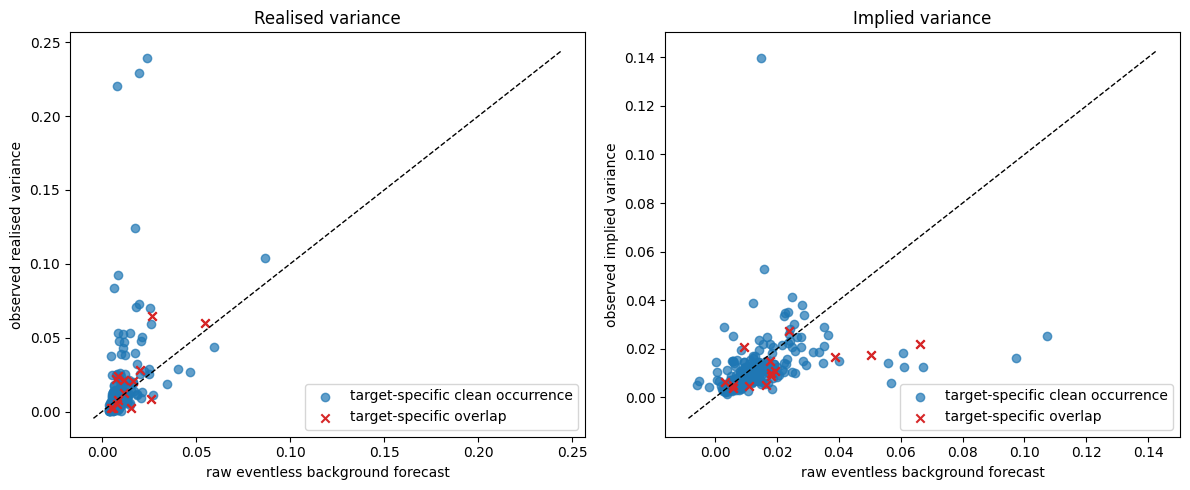

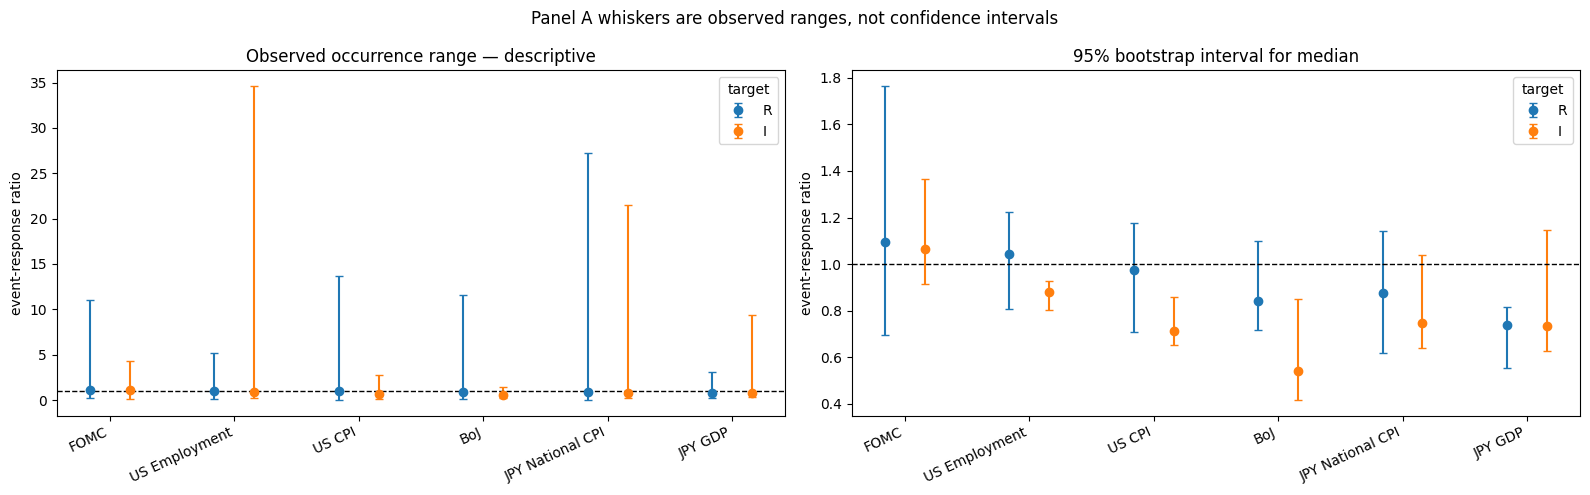

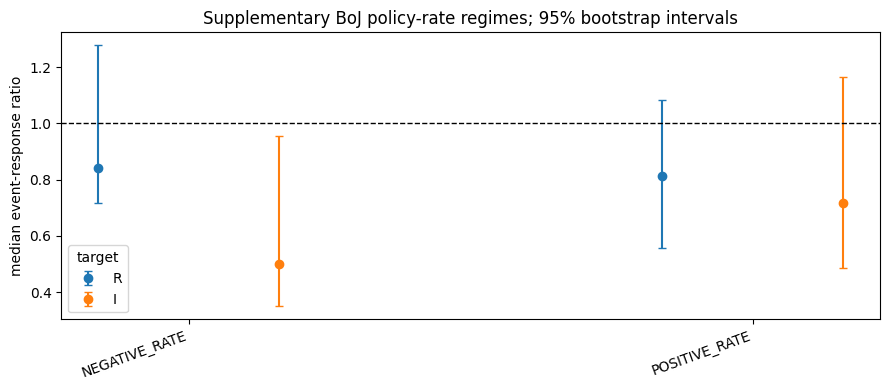

In [19]:
FIGURES.mkdir(parents=True, exist_ok=True)
figure_18_1_path = FIGURES / "18_figure_18_1_event_variance_vs_background.png"
figure_18_2_path = FIGURES / "18_figure_18_2_pooled_event_response_ratios.png"
figure_18_3_path = FIGURES / "18_figure_18_3_boj_policy_regime_response_ratios.png"
for figure_path in [figure_18_1_path, figure_18_2_path, figure_18_3_path]:
    if figure_path.exists():
        assert figure_path.is_file()
        figure_path.unlink()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, target, label in zip(
    axes, ["R", "I"], ["Realised variance", "Implied variance"]
):
    plot_data = event_weights.loc[
        event_weights["sample_split"].eq("test")
        & event_weights["target"].eq(target)
        & event_weights["equation_eligible"]
    ].copy()
    clean = plot_data.loc[plot_data["is_clean_single_family"]]
    overlap = plot_data.loc[plot_data["is_overlap"]]
    axis.scatter(
        clean["raw_background_forecast"], clean["actual"],
        alpha=0.7, label="target-specific clean occurrence",
    )
    axis.scatter(
        overlap["raw_background_forecast"], overlap["actual"],
        marker="x", color="tab:red", label="target-specific overlap",
    )
    plot_min = min(
        plot_data["raw_background_forecast"].min(),
        plot_data["actual"].min(),
    )
    plot_max = max(
        plot_data["raw_background_forecast"].max(),
        plot_data["actual"].max(),
    )
    margin = 0.02 * (plot_max - plot_min) if plot_max > plot_min else 0.01
    axis.plot(
        [plot_min - margin, plot_max + margin],
        [plot_min - margin, plot_max + margin],
        "k--", linewidth=1,
    )
    axis.set(
        xlabel="raw eventless background forecast",
        ylabel=f"observed {label.lower()}",
        title=label,
    )
    axis.legend()
fig.tight_layout()
fig.savefig(
    str(figure_18_1_path),
    dpi=160,
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
families = list(FAMILY_LABELS)
target_styles = [
    (-0.16, "R", "tab:blue"),
    (0.16, "I", "tab:orange"),
]
panel_specifications = [
    ("Observed occurrence range — descriptive", "observed_min", "observed_max"),
    ("95% bootstrap interval for median", "bootstrap_ci_lower", "bootstrap_ci_upper"),
]
for axis, (title, lower_column, upper_column) in zip(
    axes, panel_specifications
):
    for offset, target, color in target_styles:
        values = (
            table_18_6.loc[table_18_6["target"].eq(target)]
            .set_index("family")
            .reindex(families)
        )
        median_weight = values["median"].to_numpy(float)
        lower = values[lower_column].to_numpy(float)
        upper = values[upper_column].to_numpy(float)
        errors = np.vstack([
            median_weight - lower,
            upper - median_weight,
        ])
        axis.errorbar(
            np.arange(len(families)) + offset,
            median_weight,
            yerr=np.maximum(errors, 0),
            fmt="o",
            capsize=3,
            color=color,
            label=target,
        )
    axis.axhline(1, color="black", linestyle="--", linewidth=1)
    axis.set_title(title)
    axis.set_xticks(np.arange(len(families)), families, rotation=25, ha="right")
    axis.set_ylabel("event-response ratio")
    axis.legend(title="target")
panel_a_range_data = table_18_6[
    ["family", "target", "observed_min", "median", "observed_max"]
].copy()
assert panel_a_range_data["observed_min"].gt(0).all()
assert (panel_a_range_data["observed_min"] <= panel_a_range_data["median"]).all()
assert (panel_a_range_data["median"] <= panel_a_range_data["observed_max"]).all()
axes[0].set_yscale("log")
axes[0].set_ylabel("event-response ratio (log scale)")
axes[1].set_ylabel("event-response ratio (linear scale)")
fig.suptitle("Panel A whiskers are observed ranges, not confidence intervals")
fig.tight_layout()
fig.savefig(
    str(figure_18_2_path),
    dpi=160,
)
plt.show()

regime_support = boj_policy_regime_summary.groupby("policy_rate_regime")[
    "n_defined_weights"
].min()
plot_regimes = regime_support.loc[regime_support.ge(5)].index.tolist()
if len(plot_regimes) >= 2:
    fig, axis = plt.subplots(figsize=(9, 4))
    for offset, target, color in target_styles:
        values = (
            boj_policy_regime_summary.loc[
                boj_policy_regime_summary["target"].eq(target)
                & boj_policy_regime_summary["policy_rate_regime"].isin(plot_regimes)
            ]
            .set_index("policy_rate_regime")
            .reindex(plot_regimes)
        )
        median_weight = values["median"].to_numpy(float)
        errors = np.vstack([
            median_weight - values["bootstrap_ci_lower"].to_numpy(float),
            values["bootstrap_ci_upper"].to_numpy(float) - median_weight,
        ])
        axis.errorbar(
            np.arange(len(plot_regimes)) + offset,
            median_weight,
            yerr=np.maximum(errors, 0),
            fmt="o",
            capsize=3,
            color=color,
            label=target,
        )
    axis.axhline(1, color="black", linestyle="--", linewidth=1)
    axis.set_xticks(np.arange(len(plot_regimes)), plot_regimes, rotation=20, ha="right")
    axis.set_ylabel("median event-response ratio")
    axis.set_title("Supplementary BoJ policy-rate regimes; 95% bootstrap intervals")
    axis.legend(title="target")
    fig.tight_layout()
    fig.savefig(str(figure_18_3_path), dpi=160)
    plt.show()

## 18. Realised-side invariance and final integrity

Where prior N18 exports exist, realised coefficients, backgrounds, and event weights are compared numerically before overwrite. Structural assertions remain authoritative if prior exports are absent.

In [20]:
def finite_max_abs_difference(left, right):
    difference = np.abs(
        np.asarray(left, dtype=float) - np.asarray(right, dtype=float)
    )
    finite = difference[np.isfinite(difference)]
    return float(finite.max()) if len(finite) else 0.0

invariance = {
    "realised_mapping_unchanged": True,
    "realised_eventless_train_N_before": 2321,
    "realised_eventless_train_N_after": len(train_models["R"]["sample"]),
    "realised_eventless_train_validation_N_before": 3240,
    "realised_eventless_train_validation_N_after": len(
        final_models["R"]["sample"]
    ),
    "realised_active_regressors_unchanged": (
        final_models["R"]["features"] == ["R_lag1", "I_lag1"]
    ),
    "max_abs_R_coefficient_difference_vs_prior_export": np.nan,
    "max_abs_R_background_difference_vs_prior_export": np.nan,
    "max_abs_R_event_weight_difference_vs_prior_export": np.nan,
}
if len(prior_coefficients_export):
    prior_R = prior_coefficients_export.loc[
        prior_coefficients_export["target"].eq("R"),
        ["calibration_stage", "predictor", "coefficient"],
    ]
    current_R = pd.concat([
        train_coefficients.loc[train_coefficients["target"].eq("R")],
        final_coefficients.loc[final_coefficients["target"].eq("R")],
    ])[["calibration_stage", "predictor", "coefficient"]]
    aligned_R = prior_R.merge(
        current_R,
        on=["calibration_stage", "predictor"],
        suffixes=("_prior", "_current"),
        validate="one_to_one",
    )
    invariance["max_abs_R_coefficient_difference_vs_prior_export"] = (
        finite_max_abs_difference(
            aligned_R["coefficient_prior"],
            aligned_R["coefficient_current"],
        )
    )
if len(prior_forecasts_export):
    prior_R_forecasts = prior_forecasts_export.loc[
        prior_forecasts_export["target"].eq("R"),
        [
            "model_day", "sample_split", "forecast_stage",
            "raw_background_forecast",
        ],
    ]
    current_R_forecasts = forecasts.loc[
        forecasts["target"].eq("R"),
        [
            "model_day", "sample_split", "forecast_stage",
            "raw_background_forecast",
        ],
    ]
    aligned_R_forecasts = prior_R_forecasts.merge(
        current_R_forecasts,
        on=["model_day", "sample_split", "forecast_stage"],
        suffixes=("_prior", "_current"),
        validate="one_to_one",
    )
    invariance["max_abs_R_background_difference_vs_prior_export"] = (
        finite_max_abs_difference(
            aligned_R_forecasts["raw_background_forecast_prior"],
            aligned_R_forecasts["raw_background_forecast_current"],
        )
    )
if len(prior_event_weights_export):
    prior_R_weights = prior_event_weights_export.loc[
        prior_event_weights_export["target"].eq("R"),
        ["family", "model_day", "response_ratio"],
    ]
    current_R_weights = event_weights.loc[
        event_weights["target"].eq("R"),
        ["family", "model_day", "response_ratio"],
    ]
    aligned_R_weights = prior_R_weights.merge(
        current_R_weights,
        on=["family", "model_day"],
        suffixes=("_prior", "_current"),
        validate="one_to_one",
    )
    invariance["max_abs_R_event_weight_difference_vs_prior_export"] = (
        finite_max_abs_difference(
            aligned_R_weights["response_ratio_prior"],
            aligned_R_weights["response_ratio_current"],
        )
    )
realised_invariance_audit = pd.DataFrame([invariance])
assert invariance["realised_eventless_train_N_after"] == 2321
assert invariance["realised_eventless_train_validation_N_after"] == 3240
for metric in [
    "max_abs_R_coefficient_difference_vs_prior_export",
    "max_abs_R_background_difference_vs_prior_export",
    "max_abs_R_event_weight_difference_vs_prior_export",
]:
    if np.isfinite(invariance[metric]):
        assert invariance[metric] <= 1e-12

raw_background_original = forecasts[[
    "model_day", "sample_split", "forecast_stage",
    "target", "raw_background_forecast",
]].copy()
raw_background_final = forecasts[[
    "model_day", "sample_split", "forecast_stage",
    "target", "raw_background_forecast",
]].copy()
raw_backgrounds_preserved = (
    raw_background_original.equals(raw_background_final)
)
no_forecast_clipping = raw_backgrounds_preserved

primary_median_reference = pd.DataFrame([
    ("BoJ", "I", 26, 0.5418347696695014),
    ("BoJ", "R", 27, 0.8409949149068398),
    ("FOMC", "I", 31, 1.0630433877996452),
    ("FOMC", "R", 33, 1.096284123877112),
    ("JPY GDP", "I", 29, 0.7346174380644739),
    ("JPY GDP", "R", 36, 0.7388691060764789),
    ("JPY National CPI", "I", 44, 0.7465419875147755),
    ("JPY National CPI", "R", 47, 0.8741712343585759),
    ("US CPI", "I", 44, 0.7121913266658051),
    ("US CPI", "R", 51, 0.9727219061565167),
    ("US Employment", "I", 46, 0.8815979207145708),
    ("US Employment", "R", 52, 1.0434254747544935),
], columns=["family", "target", "n_valid_positive_denominator_reference", "median_reference"])
primary_median_check = table_18_6.merge(
    primary_median_reference,
    on=["family", "target"],
    validate="one_to_one",
)
assert np.array_equal(
    primary_median_check["n_valid_positive_denominator"].to_numpy(int),
    primary_median_check["n_valid_positive_denominator_reference"].to_numpy(int),
)
assert np.allclose(
    primary_median_check["median"],
    primary_median_check["median_reference"],
    rtol=1e-12,
    atol=1e-14,
)
assert (pooled_event_weights["bootstrap_median_se"].dropna() >= 0).all()
assert (pooled_event_weights["bootstrap_ci_lower"].dropna() <= pooled_event_weights["bootstrap_ci_upper"].dropna()).all()
assert (pooled_event_weights["observed_min"].dropna() <= pooled_event_weights["median"].dropna()).all()
assert (pooled_event_weights["median"].dropna() <= pooled_event_weights["observed_max"].dropna()).all()
assert (pooled_event_weights["q25"].dropna() <= pooled_event_weights["median"].dropna()).all()
assert (pooled_event_weights["median"].dropna() <= pooled_event_weights["q75"].dropna()).all()
assert common_valid_event_comparison["event_id"].is_unique
assert event_weight_component_summary["n_defined_weights"].gt(0).all()
assert np.array_equal(
    boj_policy_regime_mapping["realised_model_day"].to_numpy(),
    canonical_boj_occurrences["realised_model_day"].to_numpy(),
)
assert design_freeze["boj_regime_analysis_role"] == "supplementary interpretation only"
assert set(boj_regime_coverage["sample"]) == {
    "FULL_CANONICAL_BOJ", "PRIMARY_CLEAN_TEST_BOJ"
}
assert boj_regime_coverage["n_with_rate_metadata"].le(
    boj_regime_coverage["n_total_boj_events"]
).all()
primary_paired_sample_counts = table_18_6.loc[
    table_18_6["target"].eq("R"),
    ["family", "n_event_occurrences"],
].merge(
    realised_implied_weight_comparison[
        ["family", "n_common_valid_events"]
    ],
    on="family",
    validate="one_to_one",
)
assert primary_paired_sample_counts[[
    "n_event_occurrences", "n_common_valid_events"
]].ge(0).all().all()

all_coefficients = pd.concat(
    [train_coefficients, final_coefficients], ignore_index=True
)
calibration_summary = pd.concat([
    pd.DataFrame([
        residual_scale_row(model)
        for model in [*train_models.values(), *final_models.values()]
    ]),
    table_18_2.assign(record_type="calibration_support"),
], ignore_index=True, sort=False)

def bootstrap_interval(values, seed=18, repetitions=10000):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    medians = np.median(
        rng.choice(values, size=(repetitions, len(values)), replace=True),
        axis=1,
    )
    return tuple(np.quantile(medians, [0.025, 0.975]))

representative_values = (
    event_weights.loc[
        event_weights["sample_split"].eq("test")
        & event_weights["is_clean_single_family"]
        & event_weights["weight_defined"]
    ]
    .sort_values(["family", "target"])
    .groupby(["family", "target"])
    .first()["response_ratio"]
    .to_numpy(float)
)
bootstrap_reproducible = (
    bootstrap_interval(representative_values)
    == bootstrap_interval(representative_values)
)

def summary_stats(values):
    values=np.asarray(values,dtype=float)
    return {"median":float(np.median(values)) if len(values) else np.nan,"mean":float(np.mean(values)) if len(values) else np.nan,"Q25":float(np.quantile(values,.25)) if len(values) else np.nan,"Q75":float(np.quantile(values,.75)) if len(values) else np.nan,"IQR":float(np.quantile(values,.75)-np.quantile(values,.25)) if len(values) else np.nan,"fraction_above_1":float(np.mean(values>1)) if len(values) else np.nan,"fraction_below_1":float(np.mean(values<1)) if len(values) else np.nan}
summary_rows=[]
for (target,family,split),group in event_weights.groupby(["target","family","sample_split"],dropna=False):
    valid=group.loc[group.weight_defined,"response_ratio"]
    summary_rows.append({"target":target,"event_family":family,"sample_split":split,"n_total_occurrences":len(group),"n_clean_single_family":int(group.is_clean_single_family.sum()),"n_defined_weights":int(group.weight_defined.sum()),**summary_stats(valid)})
corrected_event_weight_summary=pd.DataFrame(summary_rows)
comparison_rows=[]
old_i=prior_event_weights_export.loc[prior_event_weights_export.target.eq("I")].copy() if len(prior_event_weights_export) else pd.DataFrame()
new_i=event_weights.loc[event_weights.target.eq("I")].copy()
for family in FAMILY_LABELS:
    changed=timing_correction_audit.loc[timing_correction_audit.event_family.eq(family)]
    old_test=old_i.loc[(old_i.family.eq(family))&(old_i.sample_split.eq("test"))] if len(old_i) else pd.DataFrame()
    new_test=new_i.loc[(new_i.family.eq(family))&(new_i.sample_split.eq("test"))]
    both=(old_i.loc[old_i.family.eq(family),["event_id","response_ratio","weight_defined"]].rename(columns={"response_ratio":"old_weight","weight_defined":"old_defined"}).merge(new_i.loc[new_i.family.eq(family),["event_id","response_ratio","weight_defined"]].rename(columns={"response_ratio":"new_weight","weight_defined":"new_defined"}),on="event_id",how="inner") if len(old_i) else pd.DataFrame())
    comparable=both.loc[both.old_defined&both.new_defined] if len(both) else both
    old_values=old_test.loc[old_test.weight_defined,"response_ratio"] if len(old_test) else []
    new_values=new_test.loc[new_test.weight_defined,"response_ratio"]
    comparison_rows.append({"event_family":family,"old_implied_target_convention":"APPROXIMATE_10AM_TARGET_SPECIFIC_SHIFT","new_implied_target_convention":"SAME_EMPIRICAL_MODEL_DAY_AS_EVENT","n_occurrences":len(changed),"n_implied_target_changed":int(changed.mapping_changed.sum()),"fraction_changed":float(changed.mapping_changed.mean()),"old_defined_TEST_n":int(len(old_values)),"new_defined_TEST_n":int(len(new_values)),"old_median_I_response_ratio":float(np.median(old_values)) if len(old_values) else np.nan,"new_median_I_response_ratio":float(np.median(new_values)) if len(new_values) else np.nan,"median_difference":float(np.median(new_values)-np.median(old_values)) if len(new_values) and len(old_values) else np.nan,"comparable_defined_n":int(len(comparable)),"median_old_weight_comparable":float(np.median(comparable.old_weight)) if len(comparable) else np.nan,"median_new_weight_comparable":float(np.median(comparable.new_weight)) if len(comparable) else np.nan,"rank_correlation_old_new":float(comparable.old_weight.corr(comparable.new_weight,method="spearman")) if len(comparable)>=2 else np.nan})
implied_event_weight_timing_comparison=pd.DataFrame(comparison_rows)
timing_correction_metadata=pd.DataFrame([("iv_security","USDJPYVON"),("iv_source","Bloomberg BGN"),("iv_tenor","ON"),("iv_pricing_hours_ny","17:00-16:59"),("iv_daily_observation_interpretation","END_OF_BLOOMBERG_PRICING_DAY_STATE"),("event_alignment_method","SAME_EMPIRICAL_MODEL_DAY_AS_EVENT"),("approximate_10am_iv_cut_used_for_production",False),("linus_equation_5_used",False),("prior_alignment_status","Previously used target-specific implied-day shifts are superseded for production by verified Bloomberg pricing-hours metadata."),("edge_1659_to_1700_occurrences",len(edge_case_audit))],columns=["field","value"])
statuses = {
    "notebook16_contract_loaded": True,
    "notebook17_exercise2_complete": parse_bool(spec17["exercise_2_complete"]),
    "model_day_unique": panel["model_day"].is_unique,
    "model_day_monotonic": panel["model_day"].is_monotonic_increasing,
    "states_not_reindexed": panel[[
        "model_day", "Q", "R", "I",
    ]].equals(state_snapshot),
    "lags_constructed_before_event_mask": len(lag_columns) == 36,
    "lags_preserved_after_event_merge": lags_preserved_after_event_merge,
    "six_family_universe_frozen": set(FAMILY_LABELS) == set(
        occurrences["family"]
    ),
    "component_rows_collapsed": not occurrences.duplicated(
        ["family", "realised_model_day"]
    ).any(),
    "realised_mapping_unchanged": invariance["realised_mapping_unchanged"],
    "same_model_day_implied_alignment_applied": occurrences["implied_model_day"].eq(occurrences["realised_model_day"]).all(),
    "alignment_selected_from_verified_bloomberg_metadata": (
        design_freeze["alignment_selection_sample"] == "VERIFIED_BLOOMBERG_METADATA"
    ),
    "bloomberg_session_edge_clear": edge_case_audit.empty,
    "linus_equation_5_unused": not bool(design_freeze["linus_equation_5_used"]),
    "target_specific_eventless_masks": True,
    "overlaps_masked_once_per_target": all(
        (
            ~panel.loc[
                panel[f"{target}_is_overlap"]
                & panel[f"{target}_base_eligible"],
                f"{target}_eventless_eligible",
            ]
        ).all()
        for target in ["R", "I"]
    ),
    "train_eventless_fit_complete": all(
        len(model["sample"]) > 0 for model in train_models.values()
    ),
    "train_validation_eventless_fit_complete": all(
        len(model["sample"]) > 0 for model in final_models.values()
    ),
    "validation_uses_train_fit": validation_forecasts[
        "forecast_stage"
    ].eq("validation_oos_background").all(),
    "test_uses_train_validation_fit": test_backgrounds[
        "forecast_stage"
    ].eq("test_oos_background").all(),
    "raw_backgrounds_preserved": raw_backgrounds_preserved,
    "no_forecast_clipping": no_forecast_clipping,
    "strict_positive_denominator_rule": (
        event_weights["weight_defined"]
        == (
            event_weights["target_model_day_available"]
            & event_weights["equation_eligible"]
            & event_weights["raw_background_forecast"].gt(0)
        )
    ).all(),
    "event_weight_identity": np.allclose(
        event_weights.loc[defined, "event_weight"],
        event_weights.loc[defined, "actual"]
        / event_weights.loc[defined, "raw_background_forecast"],
        rtol=1e-12,
        atol=1e-14,
    ),
    "undefined_rows_retained": event_weights.loc[
        ~event_weights["weight_defined"], "undefined_reason"
    ].ne("").all(),
    "primary_pooling_complete": len(table_18_6) == 12,
    "overlap_sensitivity_complete": len(table_18_s1) == 12,
    "common_valid_sensitivity_complete": len(table_18_s2) == 12,
    "bootstrap_reproducible": bootstrap_reproducible,
    "bootstrap_median_standard_errors_complete": (
        pooled_event_weights["bootstrap_median_se"].notna().all()
    ),
    "event_weight_component_summary_complete": (
        len(event_weight_component_summary) == 12
    ),
    "realised_implied_common_valid_comparison_complete": (
        len(realised_implied_weight_comparison) == len(FAMILY_LABELS)
    ),
    "boj_regime_analysis_supplementary": (
        design_freeze["boj_regime_analysis_role"]
        == "supplementary interpretation only"
    ),
    "ordinary_ratio_diagnostic_complete": len(
        ordinary_response_ratio_summary
    ) == 4,
    "rv_retention_audit_complete": len(event_rv_retention_audit) > 0,
    "nonpositive_implied_audit_complete": (
        set(nonpositive_implied_background_summary["sample_split"])
        == {"train", "validation", "test"}
    ),
    "linear_stability_diagnostic_reporting_only": not bool(
        linear_stability_diagnostics.loc[
            0, "estimator_or_prediction_changed_by_diagnostic"
        ]
    ),
    "realised_side_invariant": (
        invariance["realised_eventless_train_N_after"] == 2321
        and invariance["realised_eventless_train_validation_N_after"] == 3240
    ),
}
integrity_status_names = list(statuses)
statuses["exercise_3_pipeline_complete"] = all(
    bool(statuses[name]) for name in integrity_status_names
)
statuses["all_six_families_have_estimable_primary_R_pool"] = (
    table_18_6.loc[
        table_18_6["target"].eq("R"),
        "n_valid_positive_denominator",
    ].ge(2).all()
)
statuses["all_six_families_have_estimable_primary_I_pool"] = (
    table_18_6.loc[
        table_18_6["target"].eq("I"),
        "n_valid_positive_denominator",
    ].ge(2).all()
)
statuses["exercise_3_primary_results_complete"] = bool(
    statuses["exercise_3_pipeline_complete"]
    and statuses["all_six_families_have_estimable_primary_R_pool"]
    and statuses["all_six_families_have_estimable_primary_I_pool"]
)

primary_specification = pd.DataFrame([{
    **design_freeze,
    **statuses,
    "RUN_ID": RUN_ID,
    "iv_specification": spec16["iv_specification"],
    "iv_column": IV_COLUMN,
    "final_R_eventless_N": len(final_models["R"]["sample"]),
    "final_I_eventless_N": len(final_models["I"]["sample"]),
    "TRAIN_start": split_dates.loc["train", "min"],
    "TRAIN_end": split_dates.loc["train", "max"],
    "VALIDATION_start": split_dates.loc["validation", "min"],
    "VALIDATION_end": split_dates.loc["validation", "max"],
    "TEST_start": split_dates.loc["test", "min"],
    "TEST_end": split_dates.loc["test", "max"],
}])
display(realised_invariance_audit)
display(pd.Series(statuses).rename("status").to_frame())
assert statuses["exercise_3_pipeline_complete"]

,realised_mapping_unchanged,realised_eventless_train_N_before,realised_eventless_train_N_after,realised_eventless_train_validation_N_before,realised_eventless_train_validation_N_after,realised_active_regressors_unchanged,max_abs_R_coefficient_difference_vs_prior_export,max_abs_R_background_difference_vs_prior_export,max_abs_R_event_weight_difference_vs_prior_export
0,True,2321,2321,3240,3240,True,9.020562e-17,9.974660e-17,3.552714e-15


,status
notebook16_contract_loaded,True
notebook17_exercise2_complete,True
model_day_unique,True
model_day_monotonic,True
states_not_reindexed,True
lags_constructed_before_event_mask,True
lags_preserved_after_event_merge,True
six_family_universe_frozen,True
component_rows_collapsed,True
realised_mapping_unchanged,True


## 19. Authoritative exports

Existing N18 filenames are preserved where possible. New target-specific mapping and diagnostic exports make the revised convention explicit for later N19/N20 updates.

In [21]:
exports = {
    "18_event_family_mapping.csv": event_family_mapping,
    "18_event_mapping_audit.csv": mapping_audit,
    "18_event_occurrences.csv": occurrences,
    "18_event_day_flags.csv": event_day_flags,
    "18_target_specific_event_mapping.csv": target_specific_event_mapping,
    "18_eventless_coefficients.csv": all_coefficients,
    "18_eventless_calibration_summary.csv": calibration_summary,
    "18_eventless_forecasts.csv": forecasts,
    "18_forecast_metrics.csv": eventless_forecast_metrics,
    "18_validation_background_comparison.csv": table_18_3,
    "18_positivity_audit.csv": table_18_5,
    "18_event_response_weights.csv": event_weights,
    "18_pooled_event_weights.csv": pooled_event_weights,
    "18_event_weight_component_summary.csv": event_weight_component_summary,
    "18_realised_implied_weight_comparison.csv": realised_implied_weight_comparison,
    "18_boj_policy_regime_mapping.csv": boj_policy_regime_mapping,
    "18_boj_policy_regime_summary.csv": boj_policy_regime_summary,
    "18_common_valid_event_comparison.csv": common_valid_event_comparison,
    "18_ordinary_response_ratios.csv": ordinary_response_ratios,
    "18_ordinary_response_ratio_summary.csv": ordinary_response_ratio_summary,
    "18_event_rv_retention_audit.csv": event_rv_retention_audit,
    "18_nonpositive_implied_background_days.csv": nonpositive_implied_background_days,
    "18_nonpositive_implied_background_summary.csv": nonpositive_implied_background_summary,
    "18_linear_stability_diagnostics.csv": linear_stability_diagnostics,
    "18_realised_invariance_audit.csv": realised_invariance_audit,
    "18_primary_specification.csv": primary_specification,
    "18_bloomberg_timing_correction_audit.csv": timing_correction_audit,
    "18_implied_event_weight_timing_comparison.csv": implied_event_weight_timing_comparison,
    "18_corrected_event_mapping.csv": target_specific_event_mapping,
    "18_corrected_event_weight_summary.csv": corrected_event_weight_summary,
    "18_timing_correction_metadata.csv": timing_correction_metadata,
}
for filename, frame in exports.items():
    frame.to_csv(PROCESSED / filename, index=False)
    reloaded = pd.read_csv(PROCESSED / filename)
    assert len(reloaded) == len(frame), filename
print(f"Wrote {len(exports)} authoritative Notebook 18 exports.")

Wrote 31 authoritative Notebook 18 exports.


## Exercise 3 summary

Individual event weights remain actual-to-target-specific-eventless-background response ratios, and the primary family statistic remains the median over clean TEST occurrences. Historical min-to-max ranges, quartiles, and IQR describe dispersion of individual occurrences; they are not statistical uncertainty. The bootstrap standard error and retained 95% percentile-bootstrap interval quantify uncertainty in the family median, and the percentile interval may be asymmetric for a skewed weight distribution. The reference ratio of one means exact equality between an observed target and its model-estimated background for that occurrence; it is not an empirically calibrated ordinary-day median.

A ratio below one means that an observed target was below its model-estimated ordinary/eventless background for the typical pooled occurrence, not that an event reduces volatility or a negative causal treatment effect. Realised and implied ratios have different target-specific counterfactual denominators, so they cannot be compared as though they share a common scale. The common-valid R/I comparison is a paired sensitivity diagnostic and can have a different sample size from the primary clean pool. A realised ratio exceeding an implied ratio is consistent with event-session realised movement and post-announcement uncertainty resolution in the implied state, but this is an economic interpretation rather than an identified mechanism.

The BoJ policy-rate-sign breakdown is supplementary interpretation using audited rate metadata only. It does not change the canonical Bloomberg event universe, occurrence timestamps, eventless calibration, or all-BoJ primary pooled result. Historical canonical BoJ metadata coverage and primary clean TEST BoJ metadata coverage are reported separately. Ordinary ratios, RV retention, non-positive implied backgrounds, and companion stability remain separate diagnostics; none redefines the raw event weight or changes the estimator.

In [22]:
test_event_positivity = table_18_5.loc[
    table_18_5["sample_split"].eq("test")
    & table_18_5["group_type"].eq("STATUS")
    & table_18_5["group_value"].eq("ANY_TARGET_EVENT")
].set_index("target")
print(
    "Verified Bloomberg BGN USDJPYVON pricing metadata is encoded: "
    "R and I both use the event-containing empirical model day."
)
print(
    "Final calibration N:",
    {
        target: len(final_models[target]["sample"])
        for target in ["R", "I"]
    },
)
print(
    "TEST targeted-event positive backgrounds:",
    {
        target: (
            int(test_event_positivity.loc[target, "n_positive"]),
            int(test_event_positivity.loc[target, "n_forecasts"]),
        )
        for target in ["R", "I"]
    },
)
print(
    "No Bloomberg proprietary snapshot time is claimed. "
    "No TEST result selected alignment, specification, positivity, or pooling."
)
display(alignment_mapping_summary)
display(ordinary_response_ratio_summary)
display(linear_stability_diagnostics)

Verified Bloomberg BGN USDJPYVON pricing metadata is encoded: R and I both use the event-containing empirical model day.
Final calibration N: {'R': 3240, 'I': 2547}
TEST targeted-event positive backgrounds: {'R': (260, 260), 'I': (234, 237)}
No Bloomberg proprietary snapshot time is claimed. No TEST result selected alignment, specification, positivity, or pooling.


,event_family,n_occurrences,n_mapping_changed,fraction_changed
0,BoJ,221,0,0.0
1,FOMC,189,0,0.0
2,JPY GDP,174,0,0.0
3,JPY National CPI,277,0,0.0
4,US CPI,277,0,0.0
5,US Employment,276,0,0.0


,target,sample_split,n_eligible,n_valid,valid_fraction,mean,median,q25,q75
0,I,test,834,799,0.958034,1.406319,0.965793,0.702224,1.509225
1,I,validation,843,832,0.986951,1.872463,1.071467,0.791607,1.498781
2,R,test,922,922,1.000000,0.962369,0.759505,0.475737,1.159037
3,R,validation,919,919,1.000000,0.672228,0.524664,0.357705,0.796268


,calibration_stage,endogenous_state_ordering,Q_lag_treatment,sum_implied_own_I_lag_coefficients,spectral_radius,n_eigenvalues_modulus_gt_1,n_eigenvalues_modulus_ge_1,largest_modulus_1,largest_modulus_2,largest_modulus_3,largest_modulus_4,largest_modulus_5,estimator_or_prediction_changed_by_diagnostic
0,TRAIN_PLUS_VALIDATION,"[R_t,I_t,R_(t-1),I_(t-1),...,R_(t-11),I_(t-11)]",external inputs; no recursive Q equation,1.174557,1.029162,3,3,1.029162,1.000347,1.000347,0.956851,0.956851,False
